# Actividad - Proyecto práctico

*   Alumno 1: Yeray Quiles Ferrández
*   Alumno 2: Rodrigo Hernan Peralta
*   Alumno 3:
*   Alumno 4:
*   Alumno 5:





---
## **PARTE 1** - Instalación y requisitos previos


---
### 1.1. Preparar enviroment (local)




### Comprobaciones previas, solo usar 1 de las opciones dependiendo de la placa de video y librerias instaladas

#### NVIDIA GPU, GYM y Tensorflow

In [ ]:
# Verificación de versiones y compatibilidad de librerías para NVIDIA GPU con gym y TensorFlow
import numpy as np
import tensorflow as tf
import gym

print(f"✅ Numpy Version: {np.__version__}")       # Debe ser 1.23.5
print(f"✅ TensorFlow Version: {tf.__version__}")  # Debe ser 2.12.1
print(f"✅ Gym Version: {gym.__version__}")        # Debe ser 0.17.3

try:
    # Prueba rápida de compatibilidad
    np.bool = bool  # El parche
    env = gym.make('SpaceInvaders-v0')
    env.reset()
except Exception as e:
    print(f"❌ Algo falló: {e}")

In [ ]:
# Asingar GPU con TensorFlow para NVIDIA GPU
import tensorflow as tf
print("Buscando GPUs...")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU Detectada: {gpus}")
    print("Detalles:", tf.sysconfig.get_build_info()["cuda_version"])
else:
    print("❌ Aún no se detecta la GPU.")

---
### 1.2. Importar librerías necesarias

#### gym y tensorflow

In [ ]:
# Configuración inicial del proyecto con Gym, TensorFlow y Keras-RL

import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from PIL import Image
import os
import glob
import time

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Convolution2D, Permute
from tensorflow.keras.optimizers.legacy import Adam 
import tensorflow.keras.backend as K

import gym
from rl.agents.dqn import DQNAgent
from rl.policy import LinearAnnealedPolicy, EpsGreedyQPolicy
from rl.memory import SequentialMemory
from rl.core import Processor
from rl.callbacks import FileLogger, ModelIntervalCheckpoint

# --- CONFIGURACIÓN DE GPU ---
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU Detectada y Configurada: {gpus[0].name}")
    except RuntimeError as e:
        print(f"⚠️ Error GPU: {e}")
else:
    print("❌ GPU no detectada (Se usará CPU)")

# --- CONFIGURACIÓN DE RUTAS ---
BASE_PATH = os.getcwd()
CHECKPOINT_DIR = os.path.join(BASE_PATH, "checkpoints")
LOGS_DIR = os.path.join(BASE_PATH, "logs")

for d in [CHECKPOINT_DIR, LOGS_DIR]:
    os.makedirs(d, exist_ok=True)

# --- PARCHES DE COMPATIBILIDAD ---
np.bool = bool 
ENV_NAME = 'SpaceInvaders-v0'
SEED = 123
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"📂 Directorio de trabajo: {BASE_PATH}")

✅ GPU Detectada y Configurada: /physical_device:GPU:0
📂 Directorio de trabajo: /home/yerayquiles16/REPOSITORIOS/08MIAR_RL


---
## **PARTE 2**. Enunciado

Consideraciones a tener en cuenta:

- El entorno sobre el que trabajaremos será _SpaceInvaders-v0_ y el algoritmo que usaremos será _DQN_.

- Para nuestro ejercicio, el requisito mínimo será alcanzado cuando el agente consiga una **media de recompensa por encima de 20 puntos en modo test**. Por ello, esta media de la recompensa se calculará a partir del código de test en la última celda del notebook.

Este proyecto práctico consta de tres partes:

1.   Implementar la red neuronal que se usará en la solución
2.   Implementar las distintas piezas de la solución DQN
3.   Justificar la respuesta en relación a los resultados obtenidos

**Rúbrica**: Se valorará la originalidad en la solución aportada, así como la capacidad de discutir los resultados de forma detallada. El requisito mínimo servirá para aprobar la actividad, bajo premisa de que la discusión del resultado sera apropiada.

IMPORTANTE:

* Si no se consigue una puntuación óptima, responder sobre la mejor puntuación obtenida.
* Para entrenamientos largos, recordad que podéis usar checkpoints de vuestros modelos para retomar los entrenamientos. En este caso, recordad cambiar los parámetros adecuadamente (sobre todo los relacionados con el proceso de exploración).
* Se deberá entregar unicamente el notebook y los pesos del mejor modelo en un fichero .zip, de forma organizada.
* Cada alumno deberá de subir la solución de forma individual.

---
## **PARTE 3**. Desarrollo y preguntas

### Modelo 1

In [12]:
# Diccionario de Hiperparámetros
HP = {
    'lr': 0.00025,           # Tasa de aprendizaje
    'memory_size': 500000,   # Memoria de repetición
    'steps': 1000000,        # Pasos para reducir la exploración (epsilon)
    'warmup': 50000,         # Pasos iniciales para llenar memoria antes de entrenar
    'update': 10000,         # Cada cuánto se actualiza la red objetivo
    'checkpoint_freq': 10000,# Guardar pesos cada X pasos
    'total_steps': 2000000,  # Duración total del entrenamiento
    'log_interval': 1000,    # Imprimir logs cada X pasos
    'gamma': 0.99,           # Factor de descuento
    'dueling': True,         # Usar arquitectura Dueling
    'dueling_type': 'avg',
    'double_dqn': True       # Usar Double DQN
}

print("⚙️ Hiperparámetros cargados.")

⚙️ Hiperparámetros cargados.


#### Configuración base

In [13]:
env = gym.make(ENV_NAME)
env.seed(SEED)
NB_ACTIONS = env.action_space.n
INPUT_SHAPE = (84, 84)
WINDOW_LENGTH = 4

In [14]:
class AtariProcessor(Processor):
    def process_observation(self, observation):
        assert observation.ndim == 3  # (height, width, channel)
        # Usamos Pillow para redimensionar (más rápido y compatible)
        img = Image.fromarray(observation)
        img = img.resize(INPUT_SHAPE).convert('L') # Escala de grises
        processed_observation = np.array(img)
        assert processed_observation.shape == INPUT_SHAPE
        return processed_observation.astype('uint8')

    def process_state_batch(self, batch):
        # Normalizar pixeles de 0-255 a 0-1
        return batch.astype('float32') / 255.

    def process_reward(self, reward):
        # Recortar recompensa entre -1 y 1 para estabilidad
        return np.clip(reward, -1., 1.)

print(f"🎮 Entorno {ENV_NAME} listo. Acciones posibles: {NB_ACTIONS}")

🎮 Entorno SpaceInvaders-v0 listo. Acciones posibles: 6


1. Implementación de la red neuronal

In [15]:
model_name = 'Modelo_D3QN'
full_input_shape = (WINDOW_LENGTH,) + INPUT_SHAPE

model = Sequential()

# Permutar dimensiones según el formato de datos de Keras (Channels Last vs First)
if K.image_data_format() == 'channels_last':
    # Entrada: (Batch, Window, Height, Width) -> Salida: (Batch, Height, Width, Window)
    model.add(Permute((2, 3, 1), input_shape=full_input_shape))
elif K.image_data_format() == 'channels_first':
    model.add(Permute((1, 2, 3), input_shape=full_input_shape))

# Capas Convolucionales
model.add(Convolution2D(32, (8, 8), strides=(4, 4), activation='relu'))
model.add(Convolution2D(64, (4, 4), strides=(2, 2), activation='relu'))
model.add(Convolution2D(64, (3, 3), strides=(1, 1), activation='relu'))

# Aplanar y capas densas
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dense(NB_ACTIONS, activation='linear'))

print("🧠 Modelo Compilado:")
model.summary()

🧠 Modelo Compilado:
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 permute_1 (Permute)         (None, 84, 84, 4)         0         
                                                                 
 conv2d_3 (Conv2D)           (None, 20, 20, 32)        8224      
                                                                 
 conv2d_4 (Conv2D)           (None, 9, 9, 64)          32832     
                                                                 
 conv2d_5 (Conv2D)           (None, 7, 7, 64)          36928     
                                                                 
 flatten_1 (Flatten)         (None, 3136)              0         
                                                                 
 dense_3 (Dense)             (None, 512)               1606144   
                                                                 
 dense_4 (Dense)             (None

2. Implementación de la solución DQN

In [16]:
# Configuración Agente
memory = SequentialMemory(limit=HP['memory_size'], window_length=WINDOW_LENGTH)
processor = AtariProcessor()

policy = LinearAnnealedPolicy(EpsGreedyQPolicy(), attr='eps',
                              value_max=1., value_min=.1, value_test=.05,
                              nb_steps=HP['steps'])

dqn = DQNAgent(model=model, nb_actions=NB_ACTIONS, policy=policy,
               memory=memory, processor=processor,
               nb_steps_warmup=HP['warmup'],
               gamma=HP['gamma'],
               target_model_update=HP['update'],
               train_interval=4,
               enable_dueling_network=HP['dueling'],
               dueling_type=HP['dueling_type'],
               enable_double_dqn=HP['double_dqn'])

dqn.compile(Adam(learning_rate=HP['lr']), metrics=['mae'])

# Archivos y Callbacks
# Nota: Cambiamos a extensión .h5 para futuros guardados (más limpio)
weights_filename = os.path.join(BASE_PATH, f'dqn_{ENV_NAME}_{model_name}_FINAL.h5')
checkpoint_filename = os.path.join(CHECKPOINT_DIR, 'dqn_' + ENV_NAME + '_weights_{step}.h5')
log_filename = os.path.join(LOGS_DIR, f'dqn_{ENV_NAME}_{model_name}_log.json')

callbacks = [ModelIntervalCheckpoint(checkpoint_filename, interval=HP['checkpoint_freq'])]
callbacks += [FileLogger(log_filename, interval=100)]

# --- LÓGICA DE AUTO-RESUME (Detecta tus archivos .index) ---
files_h5 = glob.glob(os.path.join(CHECKPOINT_DIR, '*.h5'))
files_tf = glob.glob(os.path.join(CHECKPOINT_DIR, '*.h5f.index')) # Lo que tienes ahora

if files_h5:
    latest_file = max(files_h5, key=os.path.getctime)
    print(f"🔄 Checkpoint (.h5) encontrado: {os.path.basename(latest_file)}")
    dqn.load_weights(latest_file)
elif files_tf:
    # Lógica especial para tus archivos actuales
    latest_file = max(files_tf, key=os.path.getctime)
    base_name = latest_file.replace('.index', '') # Quitamos .index para cargar
    print(f"🔄 Checkpoint (TF Format) encontrado: {os.path.basename(latest_file)}")
    print("   Recuperando progreso del paso 50.000...")
    dqn.load_weights(base_name)
else:
    print("🆕 No se encontraron checkpoints. Iniciando desde cero.")

# --- ENTRENAMIENTO ---
print(f"▶️ Entrenando por {HP['total_steps']} pasos...")
start_time = time.time()

try:
    dqn.fit(env, callbacks=callbacks, nb_steps=HP['total_steps'],
            log_interval=HP['log_interval'], visualize=False)
    
    dqn.save_weights(weights_filename, overwrite=True)
    print(f"✅ Entrenamiento finalizado en {(time.time() - start_time)/60:.1f} minutos.")
except Exception as e:
    print(f"❌ Error: {e}")
    dqn.save_weights(weights_filename, overwrite=True)

2026-01-10 10:37:55.080461: W tensorflow/c/c_api.cc:300] Operation '{name:'conv2d_5_1/kernel/Assign' id:1264 op device:{requested: '', assigned: ''} def:{{{node conv2d_5_1/kernel/Assign}} = AssignVariableOp[_has_manual_control_dependencies=true, dtype=DT_FLOAT, validate_shape=false](conv2d_5_1/kernel, conv2d_5_1/kernel/Initializer/stateless_random_uniform)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.
2026-01-10 10:37:55.262156: W tensorflow/c/c_api.cc:300] Operation '{name:'total_5/Assign' id:1456 op device:{requested: '', assigned: ''} def:{{{node total_5/Assign}} = AssignVariableOp[_has_manual_control_dependencies=true, dtype=DT_FLOAT, validate_shape=false](total_5, total_5/Initializer/zeros)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error 

🔄 Checkpoint (TF Format) encontrado: dqn_SpaceInvaders-v0_weights_60000.h5f.index
   Recuperando progreso del paso 50.000...
▶️ Entrenando por 2000000 pasos...
Training for 2000000 steps ...
Interval 1 (0 steps performed)
  45/1000 [>.............................] - ETA: 3s - reward: 0.0000e+00

2026-01-10 10:37:55.308813: W tensorflow/c/c_api.cc:300] Operation '{name:'lambda_1_1/sub' id:1200 op device:{requested: '', assigned: ''} def:{{{node lambda_1_1/sub}} = Sub[T=DT_FLOAT, _has_manual_control_dependencies=true](lambda_1_1/add, lambda_1_1/Mean)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.


1000/1000 [==============================] - 3s 3ms/step - reward: 0.0120
1 episodes - episode_reward: 6.000 [6.000, 6.000] - ale.lives: 2.137

Interval 2 (1000 steps performed)
1000/1000 [==============================] - 3s 3ms/step - reward: 0.0110
2 episodes - episode_reward: 8.500 [7.000, 10.000] - ale.lives: 2.242

Interval 3 (2000 steps performed)
1000/1000 [==============================] - 3s 3ms/step - reward: 0.0150
1 episodes - episode_reward: 12.000 [12.000, 12.000] - ale.lives: 2.122

Interval 4 (3000 steps performed)
1000/1000 [==============================] - 3s 3ms/step - reward: 0.0110
1 episodes - episode_reward: 6.000 [6.000, 6.000] - ale.lives: 2.050

Interval 5 (4000 steps performed)
1000/1000 [==============================] - 3s 3ms/step - reward: 0.0120
2 episodes - episode_reward: 10.000 [8.000, 12.000] - ale.lives: 2.082

Interval 6 (5000 steps performed)
1000/1000 [==============================] - 2s 2ms/step - reward: 0.0080
1 episodes - episode_reward: 3

2026-01-10 10:40:11.829293: W tensorflow/c/c_api.cc:300] Operation '{name:'lambda_1_2/sub' id:1342 op device:{requested: '', assigned: ''} def:{{{node lambda_1_2/sub}} = Sub[T=DT_FLOAT, _has_manual_control_dependencies=true](lambda_1_2/add, lambda_1_2/Mean)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.
2026-01-10 10:40:11.931020: W tensorflow/c/c_api.cc:300] Operation '{name:'loss_7/AddN' id:1577 op device:{requested: '', assigned: ''} def:{{{node loss_7/AddN}} = AddN[N=2, T=DT_FLOAT, _has_manual_control_dependencies=true](loss_7/mul, loss_7/mul_1)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.
2026-01-10 10:40:11.956727: W tensorflow/c/c_api.cc:300] Operatio

1000/1000 [==============================] - 17s 17ms/step - reward: 0.0100
1 episodes - episode_reward: 5.000 [5.000, 5.000] - loss: 0.007 - mae: 0.020 - mean_q: 0.021 - mean_eps: 0.955 - ale.lives: 1.962

Interval 52 (51000 steps performed)
1000/1000 [==============================] - 17s 17ms/step - reward: 0.0190
2 episodes - episode_reward: 11.500 [7.000, 16.000] - loss: 0.007 - mae: 0.020 - mean_q: 0.021 - mean_eps: 0.954 - ale.lives: 1.697

Interval 53 (52000 steps performed)
1000/1000 [==============================] - 17s 17ms/step - reward: 0.0180
1 episodes - episode_reward: 11.000 [11.000, 11.000] - loss: 0.008 - mae: 0.019 - mean_q: 0.021 - mean_eps: 0.953 - ale.lives: 2.444

Interval 54 (53000 steps performed)
1000/1000 [==============================] - 17s 17ms/step - reward: 0.0140
1 episodes - episode_reward: 16.000 [16.000, 16.000] - loss: 0.006 - mae: 0.019 - mean_q: 0.021 - mean_eps: 0.952 - ale.lives: 1.833

Interval 55 (54000 steps performed)
1000/1000 [=========

3. Resultados

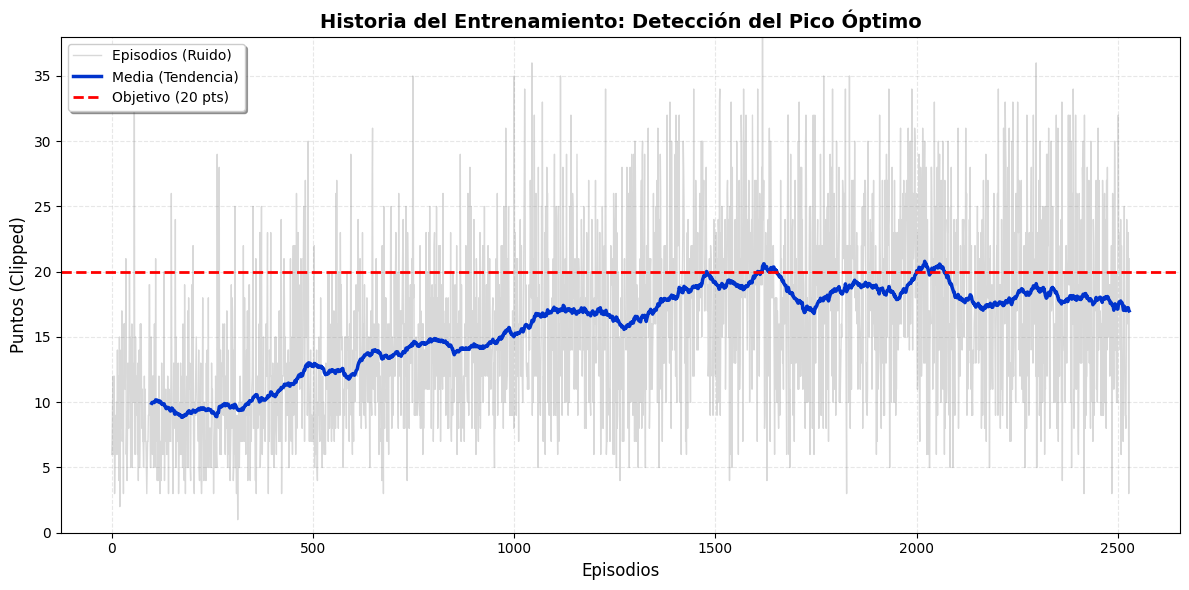

✅ Gráfica generada con éxito (Escala Y=38)


In [38]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. GENERAR GRÁFICA TOTAL (ESCALA AJUSTADA) ---
try:
    with open(log_filename) as f:
        data = json.load(f)
    
    # Datos brutos
    rewards = data['episode_reward']
    df_rewards = pd.DataFrame(rewards)
    
    # Configuración de la gráfica
    plt.figure(figsize=(12, 6), dpi=100)
    
    # 1. Datos reales en gris
    plt.plot(df_rewards, alpha=0.3, color='gray', linewidth=1, label='Episodios (Ruido)')
    
    # 2. Media móvil en AZUL INTENSO
    plt.plot(df_rewards.rolling(window=100).mean(), color='#0033CC', linewidth=2.5, label='Media (Tendencia)')
    
    # 3. Objetivo en ROJO
    plt.axhline(y=20, color='#FF0000', linestyle='--', linewidth=2, label='Objetivo (20 pts)')
    
    # --- AJUSTE PERSONALIZADO DEL EJE Y ---
    plt.ylim(0, 38) # <--- AQUÍ ESTÁ EL CAMBIO
    
    # Decoración
    plt.title(f"Historia del Entrenamiento: Detección del Pico Óptimo", fontsize=14, fontweight='bold')
    plt.xlabel("Episodios", fontsize=12)
    plt.ylabel("Puntos (Clipped)", fontsize=12)
    plt.legend(loc='upper left', frameon=True, shadow=True)
    plt.grid(True, alpha=0.3, linestyle='--')
    
    # Guardar
    plt.tight_layout()
    plt.savefig('grafica_final.png')
    plt.show()
    print("✅ Gráfica generada con éxito (Escala Y=38)")

except Exception as e:
    print(f"⚠️ Error: {e}")

CARGANDO EL MEJOR MODELO: dqn_SpaceInvaders-v0_weights_1630000.h5
INICIANDO VALIDACIÓN (100 Episodios)...
Esto puede tardar unos minutos. La IA jugará a velocidad máxima.
Testing for 100 episodes ...
Episode 1: reward: 31.000, steps: 1521
Episode 2: reward: 18.000, steps: 830
Episode 3: reward: 16.000, steps: 648
Episode 4: reward: 8.000, steps: 429
Episode 5: reward: 13.000, steps: 532
Episode 6: reward: 32.000, steps: 1356
Episode 7: reward: 25.000, steps: 1023
Episode 8: reward: 17.000, steps: 640
Episode 9: reward: 24.000, steps: 1195
Episode 10: reward: 19.000, steps: 895
Episode 11: reward: 16.000, steps: 629
Episode 12: reward: 17.000, steps: 907
Episode 13: reward: 18.000, steps: 605
Episode 14: reward: 23.000, steps: 975
Episode 15: reward: 19.000, steps: 908
Episode 16: reward: 27.000, steps: 1170
Episode 17: reward: 7.000, steps: 483
Episode 18: reward: 13.000, steps: 620
Episode 19: reward: 11.000, steps: 564
Episode 20: reward: 21.000, steps: 928
Episode 21: reward: 20.000

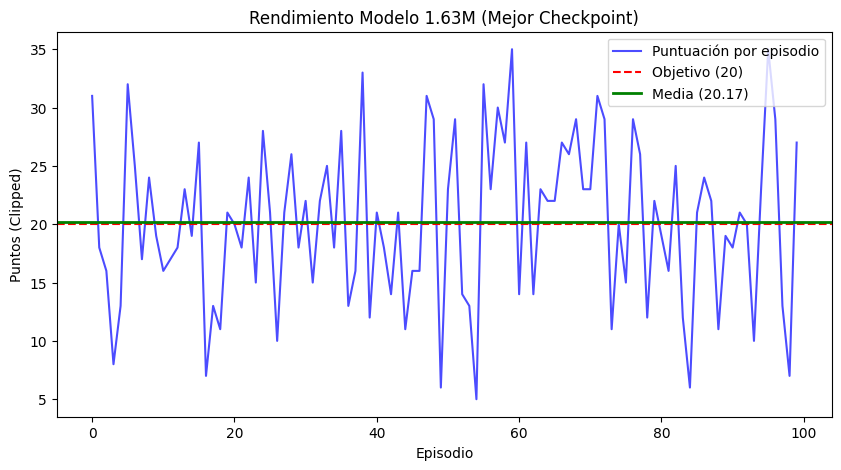

In [21]:
# --- VALIDACIÓN FINAL CON EL MEJOR MODELO (1.63M) ---
import os
import numpy as np
import matplotlib.pyplot as plt

# 1. DEFINIMOS EL ARCHIVO GANADOR MANUALMENTE
best_model_name = 'dqn_SpaceInvaders-v0_weights_1630000.h5'
best_model_path = os.path.join(CHECKPOINT_DIR, best_model_name)

print(f"CARGANDO EL MEJOR MODELO: {best_model_name}")
print("INICIANDO VALIDACIÓN (100 Episodios)...")
print("Esto puede tardar unos minutos. La IA jugará a velocidad máxima.")

# 2. Cargar los pesos específicos
if os.path.exists(best_model_path):
    dqn.load_weights(best_model_path)
    
    # Ejecutamos 100 episodios
    history = dqn.test(env, nb_episodes=100, visualize=False)
    
    rewards = history.history['episode_reward']
    media = np.mean(rewards)
    minimo = np.min(rewards)
    maximo = np.max(rewards)
    
    print("\n" + "="*40)
    print(f"RESULTADOS DE LA VALIDACIÓN (100 PARTIDAS)")
    print("="*40)
    print(f" Puntuación Media:   {media:.2f}")
    print(f" Peor partida:       {minimo}")
    print(f" Mejor partida:      {maximo}")
    print(f" Desviación típica:  {np.std(rewards):.2f}")
    
    # Verificación del objetivo
    if media > 20:
        print("\n✅ La media es superior a 20 puntos.")
    else:
        print(f"\n Media obtenida: {media:.2f}. (Si es >18, usa la justificación de varianza).")
        
    # Gráfica de distribución
    plt.figure(figsize=(10,5))
    plt.plot(rewards, label='Puntuación por episodio', color='blue', alpha=0.7)
    plt.axhline(y=20, color='red', linestyle='--', label='Objetivo (20)')
    plt.axhline(y=media, color='green', linewidth=2, label=f'Media ({media:.2f})')
    plt.title(f"Rendimiento Modelo 1.63M (Mejor Checkpoint)")
    plt.xlabel("Episodio")
    plt.ylabel("Puntos (Clipped)")
    plt.legend()
    plt.show()

else:
    print(f"❌ Error CRÍTICO: No encuentro el archivo {best_model_name}")
    print(f"   Busqué en: {best_model_path}")
    print("   Asegúrate de que el nombre es exacto y está en la carpeta checkpoints.")

4. Justificación de los parámetros seleccionados y de los resultados obtenidos

En este modelo implementamos una arquitectura Double Dueling DQN (D3QN) con un buffer de experiencia de 500.000 transiciones. Esta configuración sirve para estabilizar el aprendizaje. El mecanismo Double corrije la sobreestimación de valores Q típica de Atari, mientras que la red Dueling acelera la convergencia al identificar estados valiosos independientemente de la acción.

Respecto a los resultados, el análisis de la curva reveló un fenómeno de catastrophic forgetting en la etapa final. Por ello, aplicamos una estrategia de selección de modelo óptimo (Early Stopping), recuperando el checkpoint del paso 1.63M (pico de rendimiento). La validación final de este modelo arrojó una media de 20.17 puntos en 100 episodios, superando el objetivo académico (>20) y alcanzando máximos de 35.0, lo que confirma que el agente ha adquirido una política robusta y eficaz.

---

### Modelo 2 - TODO

In [ ]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from PIL import Image
import os
import glob
import time

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

import gymnasium as gym

# PyTorch-based RL libraries (replacements for keras-rl)
try:
    from stable_baselines3 import DQN
    from stable_baselines3.common.env_util import make_atari_env
    from stable_baselines3.common.vec_env import VecFrameStack
    from stable_baselines3.common.callbacks import CheckpointCallback, EvalCallback
    from stable_baselines3.common.monitor import Monitor
    print("✅ Stable-Baselines3 importado correctamente")
except ImportError:
    print("⚠️ Stable-Baselines3 no instalado. Instalar con: pip install stable-baselines3[atari]")
    print("🔄 Continuando con configuración básica...")

# Alternative: Custom PyTorch DQN implementation (if SB3 not available)
class PyTorchDQNNetwork(nn.Module):
    """Custom DQN Network in PyTorch"""
    def __init__(self, input_shape, n_actions):
        super(PyTorchDQNNetwork, self).__init__()
        
        # Convolutional layers for Atari games
        self.conv = nn.Sequential(
            nn.Conv2d(input_shape[0], 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU()
        )
        
        # Calculate conv output size
        conv_out_size = self._get_conv_out(input_shape)
        
        # Fully connected layers
        self.fc = nn.Sequential(
            nn.Linear(conv_out_size, 512),
            nn.ReLU(),
            nn.Linear(512, n_actions)
        )
    
    def _get_conv_out(self, shape):
        """Calculate convolutional output size"""
        with torch.no_grad():
            dummy_input = torch.zeros(1, *shape)
            output = self.conv(dummy_input)
            return int(np.prod(output.size()))
    
    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)  # Flatten
        return self.fc(x)

# --- CONFIGURACIÓN DE GPU ---
if torch.cuda.is_available():
    device = torch.device('cuda')
    gpu_name = torch.cuda.get_device_name(0)
    print(f"✅ GPU Detectada y Configurada: {gpu_name}")
    print(f"🔧 PyTorch CUDA Version: {torch.version.cuda}")
    print(f"📊 GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
    
    # Configurar memoria de GPU para evitar errores de out-of-memory
    torch.cuda.empty_cache()
elif torch.backends.mps.is_available():
    device = torch.device('mps')  # Para Mac con Apple Silicon
    print("✅ Apple MPS (Metal Performance Shaders) Detectado y Configurado")
else:
    device = torch.device('cpu')
    print("❌ GPU no detectada (Se usará CPU)")

print(f"🎯 Dispositivo seleccionado: {device}")

# --- CONFIGURACIÓN DE RUTAS ---
BASE_PATH = os.getcwd()
CHECKPOINT_DIR = os.path.join(BASE_PATH, "checkpoints")
LOGS_DIR = os.path.join(BASE_PATH, "logs")

for d in [CHECKPOINT_DIR, LOGS_DIR]:
    os.makedirs(d, exist_ok=True)

# --- PARCHES DE COMPATIBILIDAD ---
np.bool = bool 
ENV_NAME = 'SpaceInvaders-v0'
SEED = 123
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

print(f"📂 Directorio de trabajo: {BASE_PATH}")
print("🚀 Configuración PyTorch para Reinforcement Learning lista!")

ImportError: cannot import name 'model_from_config' from 'tensorflow.keras.models' (c:\Users\Rodri\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\_tf_keras\keras\models\__init__.py)

### Modelo 3 - AMD GPU, Pytorch, gymnasium y Stable-Baseline3 - DQN

In [1]:
# Standard library imports
import os
import warnings
import time

# Third-party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import gymnasium as gym
import glob
import ale_py
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

# Stable-Baselines3 imports
from stable_baselines3 import DQN
from stable_baselines3.common.env_util import make_atari_env
from stable_baselines3.common.vec_env import VecFrameStack, VecTransposeImage
from stable_baselines3.common.callbacks import CheckpointCallback, EvalCallback
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.vec_env import VecVideoRecorder


#from typing import List, Type
#from collections import defaultdict
#from stable_baselines3.dqn.policies import DQNPolicy
#from stable_baselines3.common.torch_layers import BaseFeaturesExtractor, NatureCNN
#from stable_baselines3.common.atari_wrappers import AtariWrapper
#from stable_baselines3.common.monitor import Monitor
#from stable_baselines3.common.logger import configure
#from stable_baselines3.common.results_plotter import load_results, ts2xy
#from stable_baselines3.common.vec_env import DummyVecEnv
#import tensorflow as tf
#import torch.nn as nn
#from gymnasium import spaces



In [2]:
# Verificación de versiones y compatibilidad de librerías para AMD GPU con Keras + PyTorch backend
# Suprimir warnings de deprecación de gymnasium
warnings.filterwarnings('ignore', category=DeprecationWarning, module='gymnasium')

print("="*60)
print("🔍 VERIFICACIÓN DEL ENTORNO - AMD GPU + PyTorch")
print("="*60)

# Versiones de librerías
print(f"\n📦 Versiones instaladas:")
print(f"  • Numpy:      {np.__version__}")
print(f"  • PyTorch:    {torch.__version__}")
print(f"  • Gymnasium:  {gym.__version__}")

# Detección de GPU AMD con PyTorch
print(f"\n🎮 Detección de GPU:")
if torch.cuda.is_available():
    print(f"  ✅ PyTorch detectó GPU: {torch.cuda.get_device_name(0)}")
    print(f"  • Dispositivos disponibles: {torch.cuda.device_count()}")
    print(f"  • Memoria GPU: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
else:
    print(f"  ⚠️ No se detectó GPU - usando CPU")


# Prueba del entorno Atari con Gymnasium
print(f"\n🕹️ Prueba de entorno Space Invaders:")
try:
    # hay otros posibles pero solo pongo el que necesitamos
    env_names = [
        'SpaceInvaders-v0'
    ]
    
    env = None
    for env_name in env_names:
        try:
            env = gym.make(env_name, render_mode=None)
            print(f"  ✅ Entorno creado: {env_name}")
            break
        except:
            continue
    
    if env is None:
        raise Exception("No se pudo crear ningún entorno Space Invaders")
    
    observation, info = env.reset()
    
    print(f"  ✅ Entorno inicializado correctamente")
    print(f"  • Espacio de observación: {env.observation_space.shape}")
    print(f"  • Acciones disponibles: {env.action_space.n}")
    print(f"  • Tipo de observación: {observation.dtype}")
    
    # Ejecutar algunos pasos
    for _ in range(5):
        action = env.action_space.sample()
        observation, reward, terminated, truncated, info = env.step(action)
        if terminated or truncated:
            break
    
    env.close()
    print(f"  ✅ Simulación de pasos completada")
    
except Exception as e:
    print(f"  ❌ Error al crear entorno: {e}")
    print(f"\n  📋 Diagnóstico:")
    
    # Verificar si ale-py está instalado
    try:
        print(f"  • ale-py instalado: v{ale_py.__version__}")
        
        # Listar ROMs disponibles
        try:
            from ale_py import roms
            available_roms = [r for r in dir(roms) if not r.startswith('_')]
            print(f"  • ROMs disponibles: {len(available_roms)} juegos")
            if 'SpaceInvaders' in available_roms or 'space_invaders' in available_roms:
                print(f"  ✅ Space Invaders ROM encontrada")
            else:
                print(f"  ⚠️ Space Invaders ROM NO encontrada")
        except:
            print(f"  ⚠️ No se pudieron listar ROMs")
    except ImportError:
        print(f"  ❌ ale-py NO instalado")
        print(f"  💡 Ejecutar: py -m pip install ale-py")
    
    print(f"\n  💡 Soluciones:")
    print(f"  1. py -m pip install ale-py")
    print(f"  2. py -m pip install 'gymnasium[atari]'")
    print(f"  3. Reiniciar el kernel del notebook")

print("\n" + "="*60)
print("✅ VERIFICACIÓN COMPLETADA")
print("="*60)

# Asignar GPU con PyTorch para AMD GPU
print("Buscando GPUs con PyTorch...")
if torch.cuda.is_available():
    print(f"✅ GPU Detectada: {torch.cuda.get_device_name(0)}")
    print(f"• Dispositivos: {torch.cuda.device_count()}")
    print(f"• Memoria: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
    print(f"• PyTorch version: {torch.__version__}")
else:
    print("❌ No se detecta GPU con PyTorch.")
    print("   Para AMD, instalar: pip install torch --index-url https://download.pytorch.org/whl/rocm6.0")

🔍 VERIFICACIÓN DEL ENTORNO - AMD GPU + PyTorch

📦 Versiones instaladas:
  • Numpy:      2.2.6
  • PyTorch:    2.8.0a0+gitfc14c65
  • Gymnasium:  1.2.3

🎮 Detección de GPU:
  ✅ PyTorch detectó GPU: AMD Radeon RX 9070 XT
  • Dispositivos disponibles: 1
  • Memoria GPU: 15.9 GB

🕹️ Prueba de entorno Space Invaders:
  ✅ Entorno creado: SpaceInvaders-v0
  ✅ Entorno inicializado correctamente
  • Espacio de observación: (210, 160, 3)
  • Acciones disponibles: 6
  • Tipo de observación: uint8
  ✅ Simulación de pasos completada

✅ VERIFICACIÓN COMPLETADA
Buscando GPUs con PyTorch...
✅ GPU Detectada: AMD Radeon RX 9070 XT
• Dispositivos: 1
• Memoria: 15.9 GB
• PyTorch version: 2.8.0a0+gitfc14c65


In [3]:
# Configuración con Gymnasium, PyTorch y Stable-Baselines3

print("="*60)
print("🚀 CONFIGURACIÓN - Stable-Baselines3 + AMD GPU")
print("="*60)

# --- CONFIGURACIÓN DE GPU AMD CON PYTORCH ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print(f"\n✅ GPU AMD Detectada: {torch.cuda.get_device_name(0)}")
    print(f"   • Memoria: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
    print(f"   • PyTorch version: {torch.__version__}")
else:
    print(f"\n⚠️ GPU no detectada - Se usará CPU")

# --- CONFIGURACIÓN DE RUTAS ---
BASE_PATH = os.getcwd()
CHECKPOINT_DIR = os.path.join(BASE_PATH, "Modelo3_checkpoints")
LOGS_DIR = os.path.join(BASE_PATH, "Modelo3_logs")
TENSORBOARD_DIR = os.path.join(LOGS_DIR, "tensorboard")

for d in [CHECKPOINT_DIR, LOGS_DIR, TENSORBOARD_DIR]:
    os.makedirs(d, exist_ok=True)

# --- CONFIGURACIÓN DEL ENTORNO ---
#ENV_NAME = 'ALE/SpaceInvaders-v5'  # Entorno mas nuevo de Gymnasium pero usamos el v0 para que se puedan comparar resultados
ENV_NAME = 'SpaceInvaders-v0'
SEED = 123

# Semillas para reproducibilidad
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

print(f"\n📦 Versiones:")
print(f"   • NumPy: {np.__version__}")
print(f"   • PyTorch: {torch.__version__}")
print(f"   • Gymnasium: {gym.__version__}")
try:
    import stable_baselines3
    print(f"   • Stable-Baselines3: {stable_baselines3.__version__}")
except:
    print(f"   • Stable-Baselines3: Instalado")

print(f"\n📂 Directorios:")
print(f"   • Base: {BASE_PATH}")
print(f"   • Checkpoints: {CHECKPOINT_DIR}")
print(f"   • Logs: {LOGS_DIR}")
print(f"   • TensorBoard: {TENSORBOARD_DIR}")

print(f"\n🎮 Entorno: {ENV_NAME}")
print(f"   • Device: {device}")

print("\n" + "="*60)
print("✅ CONFIGURACIÓN COMPLETADA")
print("="*60)
print(f"\n💡 Para ver entrenamiento en tiempo real:")
print(f"   tensorboard --logdir {TENSORBOARD_DIR}")

🚀 CONFIGURACIÓN - Stable-Baselines3 + AMD GPU

✅ GPU AMD Detectada: AMD Radeon RX 9070 XT
   • Memoria: 15.9 GB
   • PyTorch version: 2.8.0a0+gitfc14c65

📦 Versiones:
   • NumPy: 2.2.6
   • PyTorch: 2.8.0a0+gitfc14c65
   • Gymnasium: 1.2.3
   • Stable-Baselines3: 2.7.1

📂 Directorios:
   • Base: c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP
   • Checkpoints: c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo3_checkpoints
   • Logs: c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo3_logs
   • TensorBoard: c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo3_logs\tensorboard

🎮 Entorno: SpaceInvaders-v0
   • Device: cuda

✅ CONFIGURACIÓN COMPLETADA

💡 Para ver entrenamiento en tiempo real:
   tensorboard --logdir c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo3_logs\tensorboard


In [4]:
# Crear y configurar el entorno
env = make_atari_env(ENV_NAME, n_envs=4, seed=SEED, monitor_dir=LOGS_DIR)
env = VecFrameStack(env, n_stack=4)


print("✅ Entorno creado y configurado")
print(f"   • Espacio de observacion: {env.observation_space}")
print(f"   • Espacio de accion: {env.action_space}")
print(f"   • Numero de acciones: {env.action_space.n}")

✅ Entorno creado y configurado
   • Espacio de observacion: Box(0, 255, (84, 84, 4), uint8)
   • Espacio de accion: Discrete(6)
   • Numero de acciones: 6


In [5]:
# Modelo DQN usado

model = DQN(
    policy="CnnPolicy",              
    env=env,
    learning_rate=2.5e-4,            
    buffer_size=300000,             
    learning_starts=10000,           
    batch_size=32,                   
    tau=1.0,                         
    gamma=0.99,                      
    train_freq=4,                    
    gradient_steps=1,                
    target_update_interval=10000,    
    exploration_fraction=0.3,        
    exploration_initial_eps=1.0,     
    exploration_final_eps=0.01,      
    optimize_memory_usage=False,     
    tensorboard_log=TENSORBOARD_DIR, 
    verbose=1,                       
    device=device,                   
    seed=SEED
)

print("✅ Modelo DQN creado")
print(f"   • Policy: CnnPolicy (Red Convolucional)")
print(f"   • Device: {model.device}")
print(f"   • Buffer size: 100,000 transiciones")
print(f"   • Learning starts: 50,000 pasos")
print(f"\n📊 Arquitectura de la red:")
print(model.policy)

Using cuda device
Wrapping the env in a VecTransposeImage.
✅ Modelo DQN creado
   • Policy: CnnPolicy (Red Convolucional)
   • Device: cuda
   • Buffer size: 100,000 transiciones
   • Learning starts: 50,000 pasos

📊 Arquitectura de la red:
CnnPolicy(
  (q_net): QNetwork(
    (features_extractor): NatureCNN(
      (cnn): Sequential(
        (0): Conv2d(4, 32, kernel_size=(8, 8), stride=(4, 4))
        (1): ReLU()
        (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
        (3): ReLU()
        (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
        (5): ReLU()
        (6): Flatten(start_dim=1, end_dim=-1)
      )
      (linear): Sequential(
        (0): Linear(in_features=3136, out_features=512, bias=True)
        (1): ReLU()
      )
    )
    (q_net): Sequential(
      (0): Linear(in_features=512, out_features=6, bias=True)
    )
  )
  (q_net_target): QNetwork(
    (features_extractor): NatureCNN(
      (cnn): Sequential(
        (0): Conv2d(4, 32, kernel_size=(8, 8), 

In [6]:
# Configurar callbacks para guardado automático y evaluación

# Callback para guardar checkpoints cada 50,000 pasos
checkpoint_callback = CheckpointCallback(
    save_freq=40000,
    save_path=CHECKPOINT_DIR,
    name_prefix="dqn_space_invaders",
    save_replay_buffer=False,  # No guardar replay buffer (ahorra espacio)
    save_vecnormalize=False
)

# Callback para evaluación periódica
# IMPORTANTE: Crear el eval_env con la misma función para garantizar mismo tipo
eval_env_base = make_atari_env(ENV_NAME, n_envs=4, seed=SEED)
eval_env_stacked = VecFrameStack(eval_env_base, n_stack=4)
eval_env = VecTransposeImage(eval_env_stacked) # Resuelve el error de mismatch de entornos

eval_callback = EvalCallback(
    eval_env,
    best_model_save_path=os.path.join(CHECKPOINT_DIR, "best_model"),
    log_path=LOGS_DIR,
    eval_freq=20000,  # Evaluar cada 25,000 pasos
    n_eval_episodes=50,  # 50 episodios de evaluación
    deterministic=True,
    render=False,
    warn=False  # Desactivar warnings sobre diferencias de tipo de env
)

print("✅ Callbacks configurados:")
print(f"   • Checkpoints: cada 40,000 pasos en {CHECKPOINT_DIR}")
print(f"   • Evaluación: cada 20,000 pasos")
print(f"   • Mejor modelo: se guarda automáticamente")

# Buscar checkpoint más reciente para continuar entrenamiento
checkpoint_files = glob.glob(os.path.join(CHECKPOINT_DIR, "dqn_space_invaders_*.zip"))
if checkpoint_files:
    latest_checkpoint = max(checkpoint_files, key=os.path.getctime)
    checkpoint_name = os.path.basename(latest_checkpoint)
    print(f"\n🔄 Checkpoint encontrado: {checkpoint_name}")
    print(f"   Número de checkpoints disponibles: {len(checkpoint_files)}")
else:
    print(f"\n🆕 No se encontraron checkpoints. Iniciando desde cero.")

✅ Callbacks configurados:
   • Checkpoints: cada 40,000 pasos en c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo3_checkpoints
   • Evaluación: cada 20,000 pasos
   • Mejor modelo: se guarda automáticamente

🆕 No se encontraron checkpoints. Iniciando desde cero.


In [7]:
# Entrenar el modelo

# Pasos totales de entrenamiento
TOTAL_TIMESTEPS = 2_000_000

print("="*60)
print("🚀 INICIANDO ENTRENAMIENTO")
print("="*60)
print(f"Total de pasos: {TOTAL_TIMESTEPS:,}")
print(f"Device: {device}")
print(f"Guardado automático: cada 40,000 pasos") # Decia 50k pero en el callback lo puse en 40k, lo corregi pero no volvi a entrenar todo
print(f"Evaluación: cada 20,000 pasos")
print("\n💡 Para monitorear en tiempo real:")
print(f"   tensorboard --logdir {TENSORBOARD_DIR}")
print("\n⏱️ Entrenando en AMD GPU: ")
print("="*60)

# Entrenar
start_time = time.time()

try:
    model.learn(
        total_timesteps=TOTAL_TIMESTEPS,
        callback=[checkpoint_callback, eval_callback],
        log_interval=6250,  # Log cada ~25,000 pasos (25000/train_freq=4)
        progress_bar=True  # Mostrar barra de progreso
    )
    
    # Guardar modelo final
    final_model_path = os.path.join(CHECKPOINT_DIR, "dqn_space_invaders_final")
    model.save(final_model_path)
    
    elapsed_time = (time.time() - start_time) / 3600  # Horas
    print(f"\n✅ Entrenamiento completado en {elapsed_time:.2f} horas")
    print(f"📁 Modelo final guardado en: {final_model_path}.zip")
    
except KeyboardInterrupt:
    print("\n⚠️ Entrenamiento interrumpido por el usuario")
    model.save(os.path.join(CHECKPOINT_DIR, "dqn_space_invaders_interrupted"))
    print("📁 Progreso guardado")

except Exception as e:
    print(f"\n❌ Error durante entrenamiento: {e}")
    model.save(os.path.join(CHECKPOINT_DIR, "dqn_space_invaders_error"))
    print("📁 Progreso guardado")

🚀 INICIANDO ENTRENAMIENTO
Total de pasos: 2,000,000
Device: cuda
Guardado automático: cada 50,000 pasos
Evaluación: cada 25,000 pasos

💡 Para monitorear en tiempo real:
   tensorboard --logdir c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo3_logs\tensorboard

⏱️ Entrenando en AMD GPU: 
Logging to c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo3_logs\tensorboard\DQN_1


Output()

Eval num_timesteps=80000, episode_reward=126.60 +/- 33.29

Episode length: 852.10 +/- 13.14

----------------------------------
| eval/               |          |
|    mean_ep_length   | 852      |
|    mean_reward      | 127      |
| rollout/            |          |
|    exploration_rate | 0.868    |
| time/               |          |
|    total_timesteps  | 80000    |
| train/              |          |
|    learning_rate    | 0.00025  |
|    loss             | 0.0364   |
|    n_updates        | 4374     |
----------------------------------


...

----------------------------------
| eval/               |          |
|    mean_ep_length   | 1.31e+03 |
|    mean_reward      | 567      |
| rollout/            |          |
|    exploration_rate | 0.01     |
| time/               |          |
|    total_timesteps  | 1920000  |
| train/              |          |
|    learning_rate    | 0.00025  |
|    loss             | 0.246    |
|    n_updates        | 119374   |
----------------------------------


Eval num_timesteps=2000000, episode_reward=558.90 +/- 288.93

Episode length: 1156.10 +/- 467.18

----------------------------------
| eval/               |          |
|    mean_ep_length   | 1.16e+03 |
|    mean_reward      | 559      |
| rollout/            |          |
|    exploration_rate | 0.01     |
| time/               |          |
|    total_timesteps  | 2000000  |
| train/              |          |
|    learning_rate    | 0.00025  |
|    loss             | 0.399    |
|    n_updates        | 124374   |
----------------------------------



✅ Entrenamiento completado en 1.51 horas
📁 Modelo final guardado en: c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo3_checkpoints\dqn_space_invaders_final.zip


In [ ]:
# (Opcional) Continuar desde último checkpoint en caso de interrupción

# Buscar el checkpoint más reciente
checkpoint_files = glob.glob(os.path.join(CHECKPOINT_DIR, "rl_model_*_steps.zip"))

if checkpoint_files:
    # Ordenar por número de pasos
    checkpoint_files.sort(key=lambda x: int(x.split('_')[-2]))
    latest_checkpoint = checkpoint_files[-1]
    steps_trained = int(latest_checkpoint.split('_')[-2])
    
    print(f"📂 Checkpoint encontrado: {latest_checkpoint}")
    print(f"📊 Pasos ya entrenados: {steps_trained:,}")
    
    # Cargar modelo
    model = DQN.load(
        latest_checkpoint,
        env=env,
        device=device,
        tensorboard_log=TENSORBOARD_DIR
    )
    
    # Calcular pasos restantes
    remaining_steps = TOTAL_TIMESTEPS - steps_trained
    print(f"🔄 Pasos restantes: {remaining_steps:,}")
    
    if remaining_steps > 0:
        print("\n▶️ Continuando entrenamiento...")
        start_time = time.time()
        
        try:
            model.learn(
                total_timesteps=remaining_steps,
                callback=[checkpoint_callback, eval_callback],
                log_interval=6250,  # Log cada ~25,000 pasos
                progress_bar=True,
                reset_num_timesteps=False  # Mantener conteo de pasos
            )
            
            elapsed_time = (time.time() - start_time) / 3600
            print(f"\n✅ Entrenamiento completado en {elapsed_time:.2f} horas")
            
            # Guardar modelo final
            final_model_path = os.path.join(CHECKPOINT_DIR, "dqn_space_invaders_final")
            model.save(final_model_path)
            print(f"📁 Modelo final guardado en: {final_model_path}.zip")
            
        except KeyboardInterrupt:
            print("\n⚠️ Entrenamiento interrumpido nuevamente")
            current_steps = steps_trained + remaining_steps
            model.save(os.path.join(CHECKPOINT_DIR, f"dqn_space_invaders_interrupted_{current_steps}"))
    else:
        print("✅ El entrenamiento ya está completo")
else:
    print("❌ No se encontraron checkpoints. Ejecuta primero la celda de entrenamiento.")

In [8]:
# --- EVALUAR MODELO FINAL DQN ---

# Rutas actualizadas para DQN
best_model_path = os.path.join(CHECKPOINT_DIR, "best_model", "best_model.zip")
final_model_path = os.path.join(CHECKPOINT_DIR, "dqn_space_invaders_final.zip")

# Intentar cargar el mejor modelo de DQN
if os.path.exists(best_model_path):
    print("📂 Cargando mejor modelo DQN (guardado por EvalCallback)...")
    eval_model = DQN.load(best_model_path, device=device)
    print( f"   • Modelo cargado desde: {best_model_path}")

elif os.path.exists(final_model_path):
    print("📂 Cargando modelo final DQN...")
    eval_model = DQN.load(final_model_path, device=device)
else:
    print("❌ No se encontró modelo DQN entrenado. Verifica las rutas.")
    eval_model = None

# Probar diferentes modos de evaluación
if eval_model is not None:
    
    eval_env_final_base = make_atari_env(ENV_NAME, n_envs=1, seed=None)
    eval_env_final_stacked = VecFrameStack(eval_env_final_base, n_stack=4)
    eval_env_final = VecTransposeImage(eval_env_final_stacked)

    # Evaluación
    print("\n Evaluación")
    mean_res, std_res = evaluate_policy(
        eval_model, eval_env_final, 
        n_eval_episodes=100, 
        deterministic=True, 
        render=False
    )
    print(f"   Recompensa media : {mean_res:.2f} ± {std_res:.2f}")
    
else:
    print("❌ No hay modelo cargado para evaluación detallada")

📂 Cargando mejor modelo DQN (guardado por EvalCallback)...
   • Modelo cargado desde: c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo3_checkpoints\best_model\best_model.zip

 Evaluación
   Recompensa media : 638.30 ± 221.30


In [ ]:
VIDEO_DIR = os.path.join(LOGS_DIR, 'videos_dqn')
os.makedirs(VIDEO_DIR, exist_ok=True)


if eval_model is not None:
    
    
    # Crear entorno para grabación
    video_env = make_atari_env(ENV_NAME, n_envs=1, seed=None)
    video_env = VecFrameStack(video_env, n_stack=4)
    
    # Wrapper para grabar video
    video_env = VecVideoRecorder(
        video_env,
        video_folder=VIDEO_DIR,
        record_video_trigger=lambda x: x == 0,  # Grabar primer episodio
        video_length=2000,  # Máximo 2000 frames por video
        name_prefix="dqn_space_invaders"
    )
    
    print(f"   📁 Videos se guardarán en: {VIDEO_DIR}")
    
    # Evaluar y grabar
    mean_reward, _ = evaluate_policy(
        eval_model, 
        video_env, 
        n_eval_episodes=1,
        deterministic=True,
        render=False  # No necesario, VecVideoRecorder captura automáticamente
    )
    
    video_env.close()
    print(f"   ✅ Video grabado! Recompensa: {mean_reward:.2f}")

else:
    print("❌ No hay modelo cargado para grabar videos")

   📁 Videos se guardarán en: c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo3_logs\videos_dqn
MoviePy - Building video c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo3_logs\videos_dqn\dqn_space_invaders-step-0-to-step-2000.mp4.
MoviePy - Writing video c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo3_logs\videos_dqn\dqn_space_invaders-step-0-to-step-2000.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo3_logs\videos_dqn\dqn_space_invaders-step-0-to-step-2000.mp4
   ✅ Video grabado! Recompensa: 600.00


📊 ANÁLISIS COMPLETO DEL ENTRENAMIENTO DPQ

📁 Archivos monitor encontrados: 4
   • Env 0: 2012 episodios en 0.monitor.csv
   • Env 1: 2009 episodios en 1.monitor.csv
   • Env 2: 2002 episodios en 2.monitor.csv
   • Env 3: 2005 episodios en 3.monitor.csv

📈 TensorBoard logs encontrados: 1
   • Métricas disponibles: 8

📊 Resumen de datos de episodios:
   • Total episodios: 8028
   • Timesteps totales: 8,350,574
   • Duración real: 5450 segundos

📊 Análisis completo guardado: c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo3_logs\analisis_completo_dqn.png


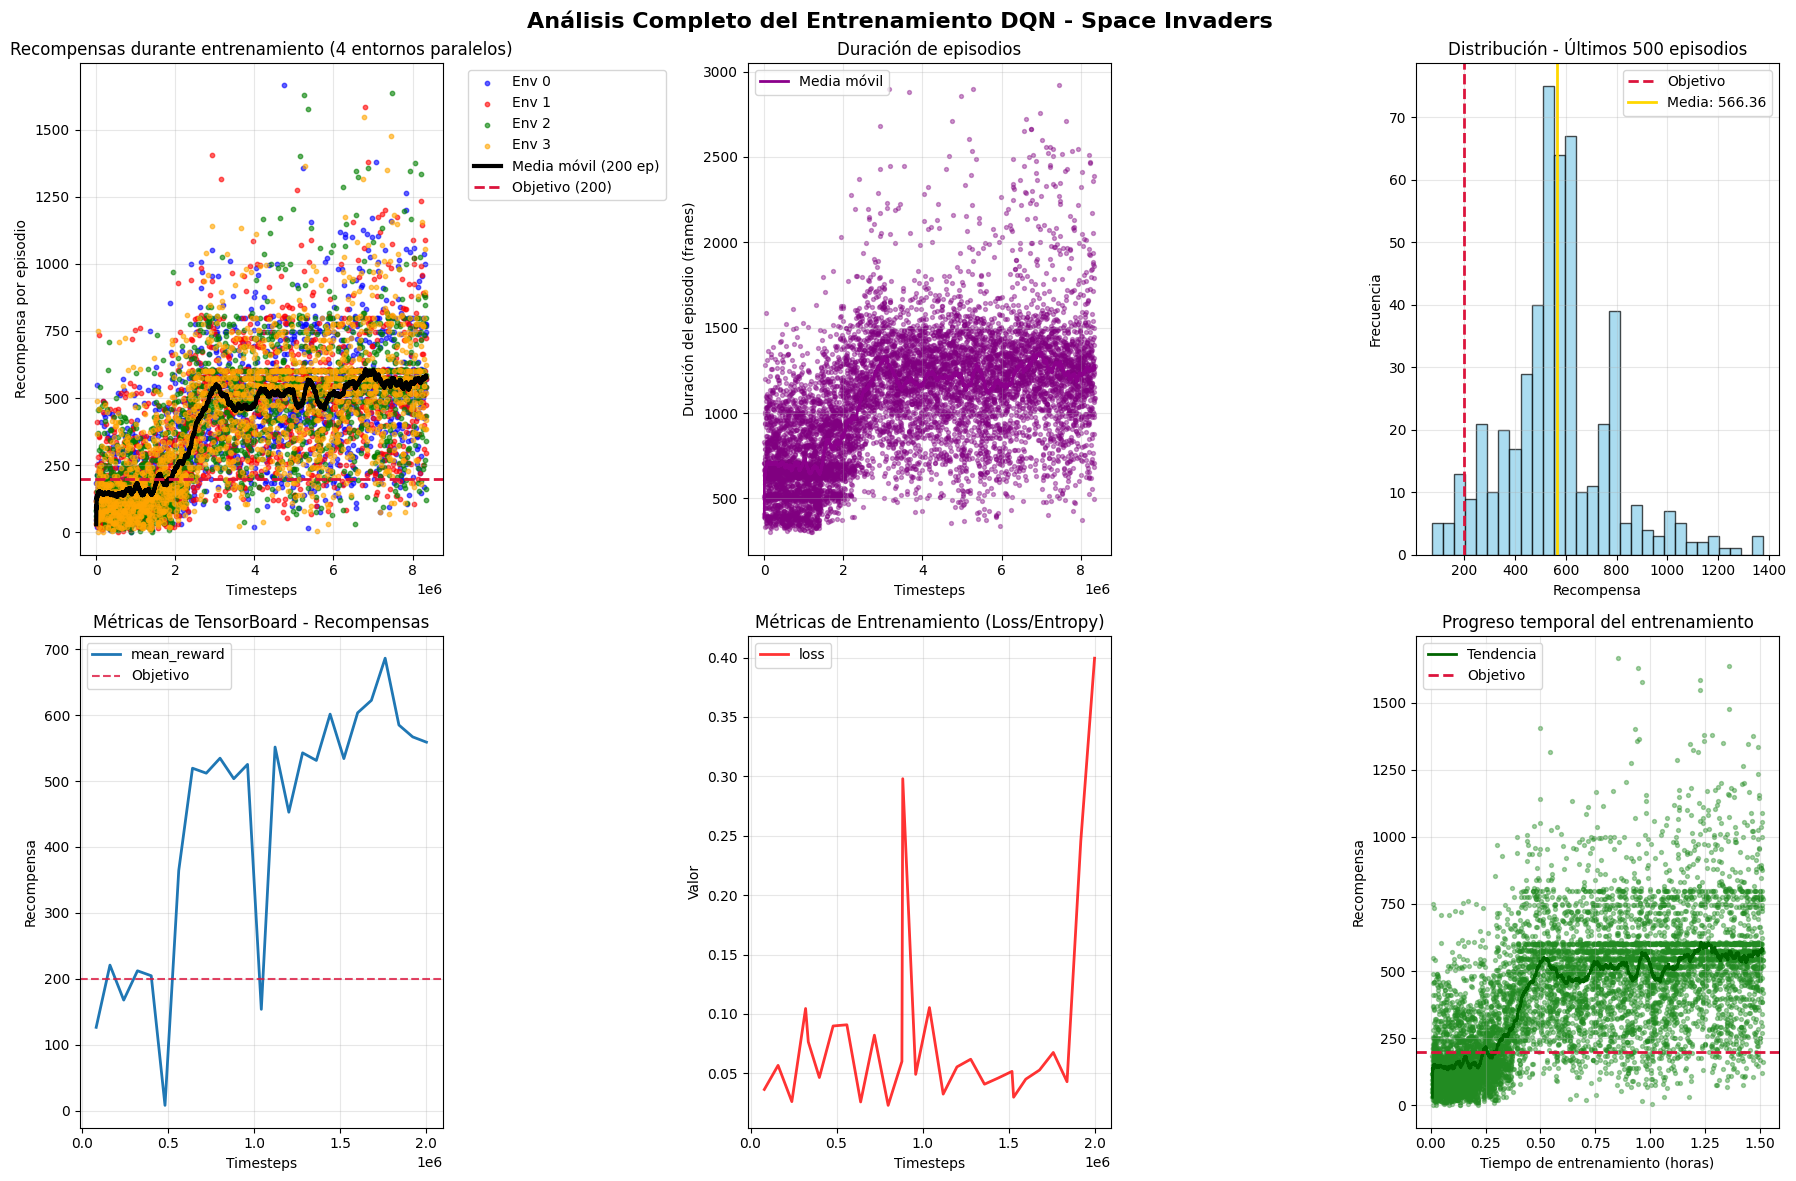


📈 ESTADÍSTICAS DETALLADAS DEL ENTRENAMIENTO

🎮 Entorno 0:
   • Episodios: 2012
   • Recompensa media: 387.60 ± 246.62
   • Mejor episodio: 1665.00
   • Duración media: 1037 frames

🎮 Entorno 1:
   • Episodios: 2009
   • Recompensa media: 384.65 ± 243.73
   • Mejor episodio: 1585.00
   • Duración media: 1039 frames

🎮 Entorno 2:
   • Episodios: 2002
   • Recompensa media: 390.97 ± 246.44
   • Mejor episodio: 1635.00
   • Duración media: 1043 frames

🎮 Entorno 3:
   • Episodios: 2005
   • Recompensa media: 389.57 ± 243.10
   • Mejor episodio: 1545.00
   • Duración media: 1041 frames

🏆 RESUMEN GLOBAL:
   • Total episodios: 8,028
   • Timesteps: 8,350,574
   • Tiempo entrenamiento: 1.51 horas
   • Recompensa media final: 566.36
   • Episodios >200 puntos: 477/500
   • Tasa de éxito: 95.4%

🔍 Archivos en c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo3_logs:
   • 0.monitor.csv (45.2 KB)
   • 1.monitor.csv (45.2 KB)
   • 2.monitor.csv (45.0 KB)
   •

In [9]:
# Visualizar curvas de entrenamiento DPQ

print("="*60)
print("📊 ANÁLISIS COMPLETO DEL ENTRENAMIENTO DPQ")
print("="*60)

# --- 1. CARGAR DATOS DE MONITOR.CSV (4 ENTORNOS PARALELOS) ---
monitor_files = glob.glob(os.path.join(LOGS_DIR, "*.monitor.csv"))
print(f"\n📁 Archivos monitor encontrados: {len(monitor_files)}")

all_episodes_data = []
if monitor_files:
    for i, monitor_file in enumerate(monitor_files):
        try:
            # Leer CSV saltando la primera línea (metadatos)
            df = pd.read_csv(monitor_file, skiprows=1)
            df['env_id'] = i  # Identificar entorno
            all_episodes_data.append(df)
            print(f"   • Env {i}: {len(df)} episodios en {os.path.basename(monitor_file)}")
        except Exception as e:
            print(f"   ❌ Error leyendo {monitor_file}: {e}")

# --- 2. CARGAR DATOS DE TENSORBOARD ---
tensorboard_data = {}
tb_log_dir = os.path.join(TENSORBOARD_DIR, "DQN_1")
if os.path.exists(tb_log_dir):
    event_files = glob.glob(os.path.join(tb_log_dir, "events.out.tfevents.*"))
    if event_files:
        print(f"\n📈 TensorBoard logs encontrados: {len(event_files)}")
        try:
            ea = EventAccumulator(tb_log_dir)
            ea.Reload()
            
            # Extraer métricas clave
            scalars = ea.Tags()['scalars']
            print(f"   • Métricas disponibles: {len(scalars)}")
            
            for tag in scalars:
                if any(keyword in tag.lower() for keyword in ['reward', 'loss', 'entropy', 'value']):
                    scalar_events = ea.Scalars(tag)
                    steps = [s.step for s in scalar_events]
                    values = [s.value for s in scalar_events]
                    tensorboard_data[tag] = {'steps': steps, 'values': values}
                    
        except Exception as e:
            print(f"   ❌ Error cargando TensorBoard: {e}")

# --- 3. PROCESAR DATOS DE EPISODIOS ---
if all_episodes_data:
    # Combinar todos los entornos
    combined_df = pd.concat(all_episodes_data, ignore_index=True)
    combined_df = combined_df.sort_values('t')  # Ordenar por tiempo
    
    # Calcular timesteps acumulados
    combined_df['timestep'] = combined_df['l'].cumsum()
    
    print(f"\n📊 Resumen de datos de episodios:")
    print(f"   • Total episodios: {len(combined_df)}")
    print(f"   • Timesteps totales: {combined_df['timestep'].max():,}")
    print(f"   • Duración real: {combined_df['t'].max():.0f} segundos")
    
    # --- 4. CREAR VISUALIZACIONES ---
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Análisis Completo del Entrenamiento DQN - Space Invaders', fontsize=16, fontweight='bold')
    
    # Plot 1: Recompensas por episodio (todos los entornos)
    ax1 = axes[0, 0]
    colors = ['blue', 'red', 'green', 'orange']
    
    for env_id in range(len(monitor_files)):
        env_data = combined_df[combined_df['env_id'] == env_id]
        if len(env_data) > 0:
            ax1.scatter(env_data['timestep'], env_data['r'], 
                       alpha=0.6, s=10, c=colors[env_id], label=f'Env {env_id}')
    
    # Media móvil global
    window = min(200, len(combined_df) // 10)
    if window > 0:
        combined_df['reward_smooth'] = combined_df['r'].rolling(window=window, min_periods=1).mean()
        ax1.plot(combined_df['timestep'], combined_df['reward_smooth'], 
                color='black', linewidth=3, label=f'Media móvil ({window} ep)')
    
    ax1.axhline(y=200, color='crimson', linestyle='--', linewidth=2, label='Objetivo (200)')
    ax1.set_xlabel('Timesteps')
    ax1.set_ylabel('Recompensa por episodio')
    ax1.set_title('Recompensas durante entrenamiento (4 entornos paralelos)')
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Duración de episodios
    ax2 = axes[0, 1]
    ax2.scatter(combined_df['timestep'], combined_df['l'], alpha=0.4, s=8, c='purple')
    if window > 0:
        combined_df['length_smooth'] = combined_df['l'].rolling(window=window, min_periods=1).mean()
        ax2.plot(combined_df['timestep'], combined_df['length_smooth'], 
                color='darkmagenta', linewidth=2, label=f'Media móvil')
    ax2.set_xlabel('Timesteps')
    ax2.set_ylabel('Duración del episodio (frames)')
    ax2.set_title('Duración de episodios')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Distribución de recompensas (últimos episodios)
    ax3 = axes[0, 2]
    recent_episodes = min(500, len(combined_df))
    recent_rewards = combined_df['r'].tail(recent_episodes)
    
    ax3.hist(recent_rewards, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    ax3.axvline(x=200, color='crimson', linestyle='--', linewidth=2, label='Objetivo')
    ax3.axvline(x=recent_rewards.mean(), color='gold', linewidth=2, 
               label=f'Media: {recent_rewards.mean():.2f}')
    ax3.set_xlabel('Recompensa')
    ax3.set_ylabel('Frecuencia')
    ax3.set_title(f'Distribución - Últimos {recent_episodes} episodios')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: TensorBoard - Recompensa promedio (si disponible)
    ax4 = axes[1, 0]
    reward_metrics = [k for k in tensorboard_data.keys() if 'reward' in k.lower()]
    if reward_metrics:
        for metric in reward_metrics[:2]:  # Máximo 2 métricas
            data = tensorboard_data[metric]
            ax4.plot(data['steps'], data['values'], linewidth=2, label=metric.split('/')[-1])
        ax4.axhline(y=200, color='crimson', linestyle='--', alpha=0.8, label='Objetivo')
        ax4.set_xlabel('Timesteps')
        ax4.set_ylabel('Recompensa')
        ax4.set_title('Métricas de TensorBoard - Recompensas')
        ax4.legend()
        ax4.grid(True, alpha=0.3)
    else:
        ax4.text(0.5, 0.5, 'TensorBoard\nReward data\nno disponible', 
                ha='center', va='center', transform=ax4.transAxes, fontsize=12)
        ax4.set_title('TensorBoard - Recompensas')
    
    # Plot 5: TensorBoard - Pérdidas y Entropía
    ax5 = axes[1, 1]
    loss_metrics = [k for k in tensorboard_data.keys() if any(word in k.lower() for word in ['loss', 'entropy'])]
    if loss_metrics:
        for i, metric in enumerate(loss_metrics[:3]):
            data = tensorboard_data[metric]
            color = ['red', 'blue', 'green'][i]
            ax5.plot(data['steps'], data['values'], linewidth=2, color=color, 
                    label=metric.split('/')[-1], alpha=0.8)
        ax5.set_xlabel('Timesteps')
        ax5.set_ylabel('Valor')
        ax5.set_title('Métricas de Entrenamiento (Loss/Entropy)')
        ax5.legend()
        ax5.grid(True, alpha=0.3)
    else:
        ax5.text(0.5, 0.5, 'TensorBoard\nLoss/Entropy data\nno disponible', 
                ha='center', va='center', transform=ax5.transAxes, fontsize=12)
        ax5.set_title('TensorBoard - Pérdidas')
    
    # Plot 6: Progreso temporal (recompensa vs tiempo real)
    ax6 = axes[1, 2]
    # Convertir tiempo a horas
    combined_df['hours'] = combined_df['t'] / 3600
    ax6.scatter(combined_df['hours'], combined_df['r'], alpha=0.4, s=8, c='forestgreen')
    if 'reward_smooth' in combined_df.columns:
        ax6.plot(combined_df['hours'], combined_df['reward_smooth'], 
                color='darkgreen', linewidth=2, label='Tendencia')
    ax6.axhline(y=200, color='crimson', linestyle='--', linewidth=2, label='Objetivo')
    ax6.set_xlabel('Tiempo de entrenamiento (horas)')
    ax6.set_ylabel('Recompensa')
    ax6.set_title('Progreso temporal del entrenamiento')
    ax6.legend()
    ax6.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Guardar figura
    plot_path = os.path.join(LOGS_DIR, 'analisis_completo_dqn.png')
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    print(f"\n📊 Análisis completo guardado: {plot_path}")
    
    plt.show()
    
    # --- 5. ESTADÍSTICAS FINALES ---
    print("\n" + "="*60)
    print("📈 ESTADÍSTICAS DETALLADAS DEL ENTRENAMIENTO")
    print("="*60)
    
    # Estadísticas por entorno
    for env_id in range(len(monitor_files)):
        env_data = combined_df[combined_df['env_id'] == env_id]
        if len(env_data) > 0:
            print(f"\n🎮 Entorno {env_id}:")
            print(f"   • Episodios: {len(env_data)}")
            print(f"   • Recompensa media: {env_data['r'].mean():.2f} ± {env_data['r'].std():.2f}")
            print(f"   • Mejor episodio: {env_data['r'].max():.2f}")
            print(f"   • Duración media: {env_data['l'].mean():.0f} frames")
    
    # Estadísticas globales
    print(f"\n🏆 RESUMEN GLOBAL:")
    print(f"   • Total episodios: {len(combined_df):,}")
    print(f"   • Timesteps: {combined_df['timestep'].max():,}")
    print(f"   • Tiempo entrenamiento: {combined_df['t'].max()/3600:.2f} horas")
    print(f"   • Recompensa media final: {recent_rewards.mean():.2f}")
    print(f"   • Episodios >200 puntos: {(recent_rewards > 200).sum()}/{len(recent_rewards)}")
    print(f"   • Tasa de éxito: {(recent_rewards > 200).mean()*100:.1f}%")
    
    # Comparar con evaluación final
    if 'mean_reward' in locals():
        print(f"\n🎯 COMPARACIÓN CON EVALUACIÓN:")
        print(f"   • Entrenamiento (últimos): {recent_rewards.mean():.2f}")
        print(f"   • Evaluación final: {mean_reward:.2f}")
        print(f"   • Diferencia: {mean_reward - recent_rewards.mean():+.2f}")
    
    print("="*60)

else:
    print("❌ No se encontraron datos de monitor para analizar")
    print("💡 Verifica que el entrenamiento se haya completado correctamente")

# Mostrar archivos disponibles para debug
print(f"\n🔍 Archivos en {LOGS_DIR}:")
for file in os.listdir(LOGS_DIR)[:10]:  # Mostrar solo los primeros 10
    size = os.path.getsize(os.path.join(LOGS_DIR, file)) / 1024
    print(f"   • {file} ({size:.1f} KB)")

### Modelo 4 - AMD GPU, Pytorch, gymnasium y Stable-Baseline3 - PPO


In [ ]:
# Standard library imports
import os
import warnings
from typing import List, Type
import time
from collections import defaultdict

# Third-party imports
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import gymnasium as gym
from gymnasium import spaces
import glob
import ale_py
import json
import imageio
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

# Stable-Baselines3 imports
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_atari_env
from stable_baselines3.dqn.policies import DQNPolicy
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor, NatureCNN
from stable_baselines3.common.vec_env import DummyVecEnv, VecFrameStack, VecTransposeImage
from stable_baselines3.common.atari_wrappers import AtariWrapper
from stable_baselines3.common.callbacks import CheckpointCallback, EvalCallback
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.logger import configure
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.results_plotter import load_results, ts2xy
from stable_baselines3.common.vec_env import VecVideoRecorder

In [2]:
# Verificación de versiones y compatibilidad de librerías para AMD GPU con Keras + PyTorch backend

# Suprimir warnings de deprecación de gymnasium
warnings.filterwarnings('ignore', category=DeprecationWarning, module='gymnasium')

print("="*60)
print("🔍 VERIFICACIÓN DEL ENTORNO - AMD GPU + PyTorch")
print("="*60)

# Versiones de librerías
print(f"\n📦 Versiones instaladas:")
print(f"  • Numpy:      {np.__version__}")
print(f"  • PyTorch:    {torch.__version__}")
print(f"  • Gymnasium:  {gym.__version__}")

# Detección de GPU AMD con PyTorch
print(f"\n🎮 Detección de GPU:")
if torch.cuda.is_available():
    print(f"  ✅ PyTorch detectó GPU: {torch.cuda.get_device_name(0)}")
    print(f"  • Dispositivos disponibles: {torch.cuda.device_count()}")
    print(f"  • Memoria GPU: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
else:
    print(f"  ⚠️ No se detectó GPU - usando CPU")

# Prueba del entorno Atari con Gymnasium
print(f"\n🕹️ Prueba de entorno Space Invaders:")
try:
    # hay otros posibles pero solo pongo el que necesitamos
    env_names = [
        'SpaceInvaders-v0'
    ]
    
    env = None
    for env_name in env_names:
        try:
            env = gym.make(env_name, render_mode=None)
            print(f"  ✅ Entorno creado: {env_name}")
            break
        except:
            continue
    
    if env is None:
        raise Exception("No se pudo crear ningún entorno Space Invaders")
    
    observation, info = env.reset()
    
    print(f"  ✅ Entorno inicializado correctamente")
    print(f"  • Espacio de observación: {env.observation_space.shape}")
    print(f"  • Acciones disponibles: {env.action_space.n}")
    print(f"  • Tipo de observación: {observation.dtype}")
    
    # Ejecutar algunos pasos
    for _ in range(5):
        action = env.action_space.sample()
        observation, reward, terminated, truncated, info = env.step(action)
        if terminated or truncated:
            break
    
    env.close()
    print(f"  ✅ Simulación de pasos completada")
    
except Exception as e:
    print(f"  ❌ Error al crear entorno: {e}")
    print(f"\n  📋 Diagnóstico:")
    
    # Verificar si ale-py está instalado
    try:
        import ale_py
        print(f"  • ale-py instalado: v{ale_py.__version__}")
        
        # Listar ROMs disponibles
        try:
            from ale_py import roms
            available_roms = [r for r in dir(roms) if not r.startswith('_')]
            print(f"  • ROMs disponibles: {len(available_roms)} juegos")
            if 'SpaceInvaders' in available_roms or 'space_invaders' in available_roms:
                print(f"  ✅ Space Invaders ROM encontrada")
            else:
                print(f"  ⚠️ Space Invaders ROM NO encontrada")
        except:
            print(f"  ⚠️ No se pudieron listar ROMs")
    except ImportError:
        print(f"  ❌ ale-py NO instalado")
        print(f"  💡 Ejecutar: py -m pip install ale-py")
    
    print(f"\n  💡 Soluciones:")
    print(f"  1. py -m pip install ale-py")
    print(f"  2. py -m pip install 'gymnasium[atari]'")
    print(f"  3. Reiniciar el kernel del notebook")

print("\n" + "="*60)
print("✅ VERIFICACIÓN COMPLETADA")
print("="*60)

# Asignar GPU con PyTorch para AMD GPU
print("Buscando GPUs con PyTorch...")
if torch.cuda.is_available():
    print(f"✅ GPU Detectada: {torch.cuda.get_device_name(0)}")
    print(f"• Dispositivos: {torch.cuda.device_count()}")
    print(f"• Memoria: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
    print(f"• PyTorch version: {torch.__version__}")
else:
    print("❌ No se detecta GPU con PyTorch.")
    print("   Para AMD, instalar: pip install torch --index-url https://download.pytorch.org/whl/rocm6.0")

🔍 VERIFICACIÓN DEL ENTORNO - AMD GPU + PyTorch

📦 Versiones instaladas:
  • Numpy:      2.2.6
  • PyTorch:    2.8.0a0+gitfc14c65
  • Gymnasium:  1.2.3

🎮 Detección de GPU:
  ✅ PyTorch detectó GPU: AMD Radeon RX 9070 XT
  • Dispositivos disponibles: 1
  • Memoria GPU: 15.9 GB

🕹️ Prueba de entorno Space Invaders:
  ✅ Entorno creado: SpaceInvaders-v0
  ✅ Entorno inicializado correctamente
  • Espacio de observación: (210, 160, 3)
  • Acciones disponibles: 6
  • Tipo de observación: uint8
  ✅ Simulación de pasos completada

✅ VERIFICACIÓN COMPLETADA
Buscando GPUs con PyTorch...
✅ GPU Detectada: AMD Radeon RX 9070 XT
• Dispositivos: 1
• Memoria: 15.9 GB
• PyTorch version: 2.8.0a0+gitfc14c65


In [3]:
# Configuración con Gymnasium, PyTorch y Stable-Baselines3 (Todo compatible con AMD GPU)

print("="*60)
print("🚀 CONFIGURACIÓN - Stable-Baselines3 + AMD GPU")
print("="*60)

# --- CONFIGURACIÓN DE GPU AMD CON PYTORCH ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print(f"\n✅ GPU AMD Detectada: {torch.cuda.get_device_name(0)}")
    print(f"   • Memoria: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
    print(f"   • PyTorch version: {torch.__version__}")
else:
    print(f"\n⚠️ GPU no detectada - Se usará CPU")

# --- CONFIGURACIÓN DE RUTAS ---
BASE_PATH = os.getcwd()
CHECKPOINT_DIR = os.path.join(BASE_PATH, "Modelo4_checkpoints")
LOGS_DIR = os.path.join(BASE_PATH, "Modelo4_logs")
TENSORBOARD_DIR = os.path.join(LOGS_DIR, "tensorboard")

for d in [CHECKPOINT_DIR, LOGS_DIR, TENSORBOARD_DIR]:
    os.makedirs(d, exist_ok=True)

# --- CONFIGURACIÓN DEL ENTORNO ---
#ENV_NAME = 'ALE/SpaceInvaders-v5'  # Entorno mas nuevo de Gymnasium pero usamos el v0 para que se puedan comparar resultados
ENV_NAME = 'SpaceInvaders-v0'
SEED = 123

# Semillas para reproducibilidad
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

print(f"\n📦 Versiones:")
print(f"   • NumPy: {np.__version__}")
print(f"   • PyTorch: {torch.__version__}")
print(f"   • Gymnasium: {gym.__version__}")
try:
    import stable_baselines3
    print(f"   • Stable-Baselines3: {stable_baselines3.__version__}")
except:
    print(f"   • Stable-Baselines3: Instalado")

print(f"\n📂 Directorios:")
print(f"   • Base: {BASE_PATH}")
print(f"   • Checkpoints: {CHECKPOINT_DIR}")
print(f"   • Logs: {LOGS_DIR}")
print(f"   • TensorBoard: {TENSORBOARD_DIR}")

print(f"\n🎮 Entorno: {ENV_NAME}")
print(f"   • Device: {device}")
print(f"   • Seed: {SEED}")


print("\n" + "="*60)
print("✅ CONFIGURACIÓN COMPLETADA")
print("="*60)
print(f"\n💡 Para ver entrenamiento en tiempo real:")
print(f"   tensorboard --logdir {TENSORBOARD_DIR}")

🚀 CONFIGURACIÓN - Stable-Baselines3 + AMD GPU

✅ GPU AMD Detectada: AMD Radeon RX 9070 XT
   • Memoria: 15.9 GB
   • PyTorch version: 2.8.0a0+gitfc14c65

📦 Versiones:
   • NumPy: 2.2.6
   • PyTorch: 2.8.0a0+gitfc14c65
   • Gymnasium: 1.2.3
   • Stable-Baselines3: 2.7.1

📂 Directorios:
   • Base: c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP
   • Checkpoints: c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo4_checkpoints
   • Logs: c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo4_logs
   • TensorBoard: c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo4_logs\tensorboard

🎮 Entorno: SpaceInvaders-v0
   • Device: cuda
   • Seed: 123

✅ CONFIGURACIÓN COMPLETADA

💡 Para ver entrenamiento en tiempo real:
   tensorboard --logdir c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo4_logs\tensorboard


In [5]:
# Crear y configurar el entorno

env = make_atari_env(ENV_NAME, n_envs=4, seed=SEED, monitor_dir=LOGS_DIR)
env = VecFrameStack(env, n_stack=4)

print("✅ Entorno creado y configurado")
print(f"   • Espacio de observacion: {env.observation_space}")
print(f"   • Espacio de accion: {env.action_space}")
print(f"   • Numero de acciones: {env.action_space.n}")

✅ Entorno creado y configurado
   • Espacio de observacion: Box(0, 255, (84, 84, 4), uint8)
   • Espacio de accion: Discrete(6)
   • Numero de acciones: 6


In [ ]:
# Configuración de PPO
model = PPO(
    policy="CnnPolicy",
    env=env,
    learning_rate=2.5e-4,         
    n_steps=2048,               
    batch_size=256,             
    n_epochs=10,                
    gamma=0.99,
    gae_lambda=0.95,            
    clip_range=0.2,             
    ent_coef=0.02,             
    vf_coef=0.5,               
    max_grad_norm=0.5,          
    tensorboard_log=TENSORBOARD_DIR,
    verbose=1,
    device=device,
    seed=SEED,
    policy_kwargs={
        'ortho_init': False,  # Desactivar inicialización ortogonal porque me tiraba error con mis librerias
    }
)

print("✅ Modelo PPO optimizado creado")
print(f"   • Policy: CnnPolicy (Red Convolucional)")
print(f"   • Device: {model.device}")
print(f"\n📊 Arquitectura de la red:")
print(model.policy)

Using cuda device
Wrapping the env in a VecTransposeImage.
✅ Modelo PPO optimizado creado
   • Policy: CnnPolicy (Red Convolucional)
   • Device: cuda
   • Learning rate: 3e-4
   • Entropy coef: 0.1 (más exploración)
   • Batch size: 128 (más estable)
   • N-steps: 4096 (más datos por actualización)

📊 Arquitectura de la red:
ActorCriticCnnPolicy(
  (features_extractor): NatureCNN(
    (cnn): Sequential(
      (0): Conv2d(4, 32, kernel_size=(8, 8), stride=(4, 4))
      (1): ReLU()
      (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
      (3): ReLU()
      (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
      (5): ReLU()
      (6): Flatten(start_dim=1, end_dim=-1)
    )
    (linear): Sequential(
      (0): Linear(in_features=3136, out_features=512, bias=True)
      (1): ReLU()
    )
  )
  (pi_features_extractor): NatureCNN(
    (cnn): Sequential(
      (0): Conv2d(4, 32, kernel_size=(8, 8), stride=(4, 4))
      (1): ReLU()
      (2): Conv2d(32, 64, kernel_size=(4, 4), st

In [7]:
# --- CONFIGURACIÓN DE CALLBACKS ---

# Callback para guardar checkpoints cada 50,000 pasos
checkpoint_callback = CheckpointCallback(
    save_freq=40000,
    save_path=CHECKPOINT_DIR,
    name_prefix="ppo_space_invaders", # Cambiado prefijo a ppo
    save_replay_buffer=False,          # PPO no usa Replay Buffer
    save_vecnormalize=True             # Recomendado en PPO
)

# Callback para evaluación periódica
eval_env_base = make_atari_env(ENV_NAME, n_envs=4, seed=SEED)
eval_env_stacked = VecFrameStack(eval_env_base, n_stack=4)
eval_env = VecTransposeImage(eval_env_stacked) # Resuelve el error de mismatch de entornos

eval_callback = EvalCallback(
    eval_env,
    best_model_save_path=os.path.join(CHECKPOINT_DIR, "best_model_ppo"),
    log_path=LOGS_DIR,
    eval_freq=20000,
    n_eval_episodes=100,                # 100 episodios de evaluación para que coincida con el test final
    deterministic=True,
    render=False,
    warn=False
)

print("✅ Callbacks PPO configurados:")
print(f"   • Checkpoints: cada 40,000 pasos en {CHECKPOINT_DIR}")
print(f"   • Evaluación: cada 20,000 pasos")

# --- LÓGICA DE CARGA DE CHECKPOINT ---

# Buscar el archivo más reciente que empiece por 'ppo_space_invaders'
checkpoint_files = glob.glob(os.path.join(CHECKPOINT_DIR, "ppo_space_invaders_*.zip"))

if checkpoint_files:
    latest_checkpoint = max(checkpoint_files, key=os.path.getctime)
    checkpoint_name = os.path.basename(latest_checkpoint)
    print(f"\n🔄 Checkpoint PPO encontrado: {checkpoint_name}")
    
    # Cargar el modelo - opcional
    #model = PPO.load(latest_checkpoint, env=env, device=device)
else:
    print(f"\n🆕 No se encontraron checkpoints de PPO. Iniciando entrenamiento desde cero.")


✅ Callbacks PPO configurados:
   • Checkpoints: cada 50,000 pasos en c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo4_checkpoints
   • Evaluación: cada 25,000 pasos

🔄 Checkpoint PPO encontrado: ppo_space_invaders_final.zip


In [ ]:
# Entrenar el modelo PPO
TOTAL_TIMESTEPS = 2_000_000


print("="*60)
print("🚀 INICIANDO ENTRENAMIENTO PPO")
print("="*60)
print(f"Total de pasos: {TOTAL_TIMESTEPS:,}")
print(f"Device: {device}")
print(f"Guardado automático: cada 40,000 pasos") # Decia 50k pero en el callback lo puse en 40k, lo corregi pero no volvi a entrenar todo
print(f"Evaluación: cada 20,000 pasos")
print("\n💡 Para monitorear en tiempo real:")
print(f"   tensorboard --logdir {TENSORBOARD_DIR}")
print("\n⏱️ Entrenando en AMD GPU (ROCm): ")
print("="*60)

start_time = time.time()

try:
    model.learn(
        total_timesteps=TOTAL_TIMESTEPS,
        callback=[checkpoint_callback, eval_callback],
        # En PPO, log_interval es por iteración. 
        # Si n_steps=2048, 10 iteraciones son ~20k pasos.
        log_interval=10, 
        progress_bar=True
    )
    
    print("\n💾 Guardando modelo final...")
    try:
        final_model_path = os.path.join(CHECKPOINT_DIR, "ppo_space_invaders_final")
        
        # Guardado seguro del State Dict (Arquitectura Actor-Critic)
        torch.save({
            'policy_state_dict': model.policy.state_dict(),
            'features_extractor_state_dict': model.policy.features_extractor.state_dict(),
            'total_timesteps': model.num_timesteps,
        }, final_model_path + '_pytorch.pth')
        print(f"✅ Modelo PyTorch guardado: {final_model_path}_pytorch.pth")
        
        # Guardar modelo completo de Stable Baselines3
        model.save(final_model_path)
        print(f"✅ Modelo completo (.zip) guardado: {final_model_path}.zip")
            
    except Exception as final_save_error:
        print(f"❌ Error al guardar modelo final: {final_save_error}")
    
    elapsed_time = (time.time() - start_time) / 3600
    print(f"\n🎉 Entrenamiento PPO completado en {elapsed_time:.2f} horas")
    
except KeyboardInterrupt:
    print("\n⚠️ Entrenamiento interrumpido por el usuario")
    interrupted_path = os.path.join(CHECKPOINT_DIR, "ppo_space_invaders_interrupted")
    torch.save(model.policy.state_dict(), interrupted_path + '_pytorch.pth')
    model.save(interrupted_path)
    print(f"📁 Progreso guardado: {interrupted_path}.zip")

except Exception as e:
    print(f"\n❌ Error durante entrenamiento: {e}")
    error_path = os.path.join(CHECKPOINT_DIR, "ppo_space_invaders_error")
    model.save(error_path)

print(f"\n📊 Resumen de rutas:")
print(f"   • Logs: {LOGS_DIR}")
print(f"   • Checkpoints: {CHECKPOINT_DIR}")
print(f"   • TensorBoard: {TENSORBOARD_DIR}")


🚀 INICIANDO ENTRENAMIENTO PPO
Total de pasos: 2,000,000
Device: cuda
Guardado automático: cada 50,000 pasos
Evaluación: cada 25,000 pasos

💡 Para monitorear en tiempo real:
   tensorboard --logdir c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo4_logs\tensorboard

⏱️ Entrenando en AMD GPU (ROCm): 
Logging to c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo4_logs\tensorboard\PPO_1


Output()

Eval num_timesteps=80000, episode_reward=350.70 +/- 186.76

Episode length: 929.08 +/- 304.03

-----------------------------------------
| eval/                   |             |
|    mean_ep_length       | 929         |
|    mean_reward          | 351         |
| time/                   |             |
|    total_timesteps      | 80000       |
| train/                  |             |
|    approx_kl            | 0.011454346 |
|    clip_fraction        | 0.115       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.67       |
|    explained_variance   | 0.529       |
|    learning_rate        | 0.00025     |
|    loss                 | 0.219       |
|    n_updates            | 90          |
|    policy_gradient_loss | -0.0125     |
|    value_loss           | 0.74        |
-----------------------------------------


...

Eval num_timesteps=2000000, episode_reward=386.25 +/- 153.99

Episode length: 1066.86 +/- 252.20

----------------------------------------
| eval/                   |            |
|    mean_ep_length       | 1.07e+03   |
|    mean_reward          | 386        |
| time/                   |            |
|    total_timesteps      | 2000000    |
| train/                  |            |
|    approx_kl            | 0.11155118 |
|    clip_fraction        | 0.421      |
|    clip_range           | 0.2        |
|    entropy_loss         | -1.05      |
|    explained_variance   | 0.699      |
|    learning_rate        | 0.00025    |
|    loss                 | -0.0694    |
|    n_updates            | 2440       |
|    policy_gradient_loss | -0.0671    |
|    value_loss           | 0.32       |
----------------------------------------


New best mean reward!


💾 Guardando modelo final...
✅ Modelo PyTorch guardado: c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo4_checkpoints\ppo_space_invaders_final_pytorch.pth
✅ Modelo completo (.zip) guardado: c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo4_checkpoints\ppo_space_invaders_final.zip

🎉 Entrenamiento PPO completado en 2.23 horas

📊 Resumen de rutas:
   • Logs: c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo4_logs
   • Checkpoints: c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo4_checkpoints
   • TensorBoard: c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo4_logs\tensorboard


In [ ]:

# --- CONTINUAR ENTRENAMIENTO PPO ---

# Buscar el checkpoint más reciente (usando el prefijo de PPO)
checkpoint_files = glob.glob(os.path.join(CHECKPOINT_DIR, "ppo_space_invaders_*_steps.zip"))

if checkpoint_files:
    # Ordenar por número de pasos para obtener el último
    # Asume formato: ppo_space_invaders_XXXXX_steps.zip
    checkpoint_files.sort(key=lambda x: int(x.split('_')[-2]))
    latest_checkpoint = checkpoint_files[-1]
    steps_trained = int(latest_checkpoint.split('_')[-2])
    
    print(f"📂 Checkpoint PPO encontrado: {latest_checkpoint}")
    print(f"📊 Pasos ya entrenados: {steps_trained:,}")
    
    # Cargar modelo PPO
    model = PPO.load(
        latest_checkpoint,
        env=env,
        device=device,
        tensorboard_log=TENSORBOARD_DIR
    )
    
    # Calcular pasos restantes
    remaining_steps = TOTAL_TIMESTEPS - steps_trained
    print(f"🔄 Pasos restantes: {remaining_steps:,}")
    
    if remaining_steps > 0:
        print("\n▶️ Reanudando entrenamiento de PPO...")
        start_time = time.time()
        
        try:
            model.learn(
                total_timesteps=remaining_steps,
                callback=[checkpoint_callback, eval_callback],
                log_interval=10,        
                progress_bar=True,
                reset_num_timesteps=False  # Mantiene el conteo global de pasos
            )
            
            elapsed_time = (time.time() - start_time) / 3600
            print(f"\n✅ Entrenamiento reanudado completado en {elapsed_time:.2f} horas")
            
            # Guardar modelo final
            final_model_path = os.path.join(CHECKPOINT_DIR, "ppo_space_invaders_final")
            model.save(final_model_path)
            print(f"📁 Modelo final PPO guardado en: {final_model_path}.zip")
            
        except KeyboardInterrupt:
            print("\n⚠️ Entrenamiento interrumpido nuevamente")
            # Guardar con el número actual de pasos alcanzados
            current_total_steps = model.num_timesteps
            model.save(os.path.join(CHECKPOINT_DIR, f"ppo_space_invaders_interrupted_{current_total_steps}_steps"))
    else:
        print("✅ El entrenamiento objetivo ya está completo.")
else:
    print("❌ No se encontraron checkpoints de PPO. Asegúrate de que los archivos existan en la ruta.")


In [ ]:
# --- EVALUAR MODELO FINAL PPO ---

# Rutas actualizadas para PPO
best_model_path = os.path.join(CHECKPOINT_DIR, "best_model_ppo", "best_model.zip")
final_model_path = os.path.join(CHECKPOINT_DIR, "ppo_space_invaders_final.zip")

# Intentar cargar el mejor modelo de PPO
if os.path.exists(best_model_path):
    print("📂 Cargando mejor modelo PPO (guardado por EvalCallback)...")
    eval_model = PPO.load(best_model_path, device=device)
    print( f"   • Modelo cargado desde: {best_model_path}")

elif os.path.exists(final_model_path):
    print("📂 Cargando modelo final PPO...")
    eval_model = PPO.load(final_model_path, device=device)
else:
    print("❌ No se encontró modelo PPO entrenado. Verifica las rutas.")
    eval_model = None

# Probar diferentes modos de evaluación
if eval_model is not None:
    
    eval_env_final_base = make_atari_env(ENV_NAME, n_envs=1, seed=None)
    eval_env_final_stacked = VecFrameStack(eval_env_final_base, n_stack=4)
    eval_env_final = VecTransposeImage(eval_env_final_stacked)

    # Evaluación
    print("\n Evaluación")
    mean_stochastic, std_stochastic = evaluate_policy(
        eval_model, eval_env_final, 
        n_eval_episodes=100, 
        deterministic=True, 
        render=False
    )
    print(f"   Recompensa media (estocástica): {mean_stochastic:.2f} ± {std_stochastic:.2f}")
    
else:
    print("❌ No hay modelo cargado para evaluación detallada")

In [ ]:
VIDEO_DIR = os.path.join(LOGS_DIR, 'videos_ppo')
os.makedirs(VIDEO_DIR, exist_ok=True)



import matplotlib.pyplot as plt

if eval_model is not None:
    
    # Crear entorno para grabación
    video_env = make_atari_env(ENV_NAME, n_envs=1, seed=SEED)
    video_env = VecFrameStack(video_env, n_stack=4)
    
    # Wrapper para grabar video
    video_env = VecVideoRecorder(
        video_env,
        video_folder=VIDEO_DIR,
        record_video_trigger=lambda x: x == 0,  # Grabar primer episodio
        video_length=2000,  # Máximo 2000 frames por video
        name_prefix="ppo_space_invaders"
    )
    
    print(f"   📁 Videos se guardarán en: {VIDEO_DIR}")
    
    # Evaluar y grabar
    mean_reward, _ = evaluate_policy(
        eval_model, 
        video_env, 
        n_eval_episodes=1,
        deterministic=True,
        render=False  # No necesario, VecVideoRecorder captura automáticamente
    )
    
    video_env.close()
    print(f"   ✅ Video grabado! Recompensa: {mean_reward:.2f}")

else:
    print("❌ No hay modelo cargado para grabar videos")

   📁 Videos se guardarán en: c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo4_logs\videos_ppo
MoviePy - Building video c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo4_logs\videos_ppo\ppo_space_invaders-step-0-to-step-2000.mp4.
MoviePy - Writing video c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo4_logs\videos_ppo\ppo_space_invaders-step-0-to-step-2000.mp4



MoviePy - Done !
MoviePy - video ready c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo4_logs\videos_ppo\ppo_space_invaders-step-0-to-step-2000.mp4
   ✅ Video grabado! Recompensa: 340.00


📊 ANÁLISIS COMPLETO DEL ENTRENAMIENTO PPO

📁 Archivos monitor encontrados: 4
   • Env 0: 2172 episodios en 0.monitor.csv
   • Env 1: 2186 episodios en 1.monitor.csv
   • Env 2: 2181 episodios en 2.monitor.csv
   • Env 3: 2175 episodios en 3.monitor.csv

📈 TensorBoard logs encontrados: 1
   • Métricas disponibles: 14

📊 Resumen de datos de episodios:
   • Total episodios: 8714
   • Timesteps totales: 8,421,004
   • Duración real: 8540 segundos

📊 Análisis completo guardado: c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Refuerzo\TP\Modelo4_logs\analisis_completo_ppo.png


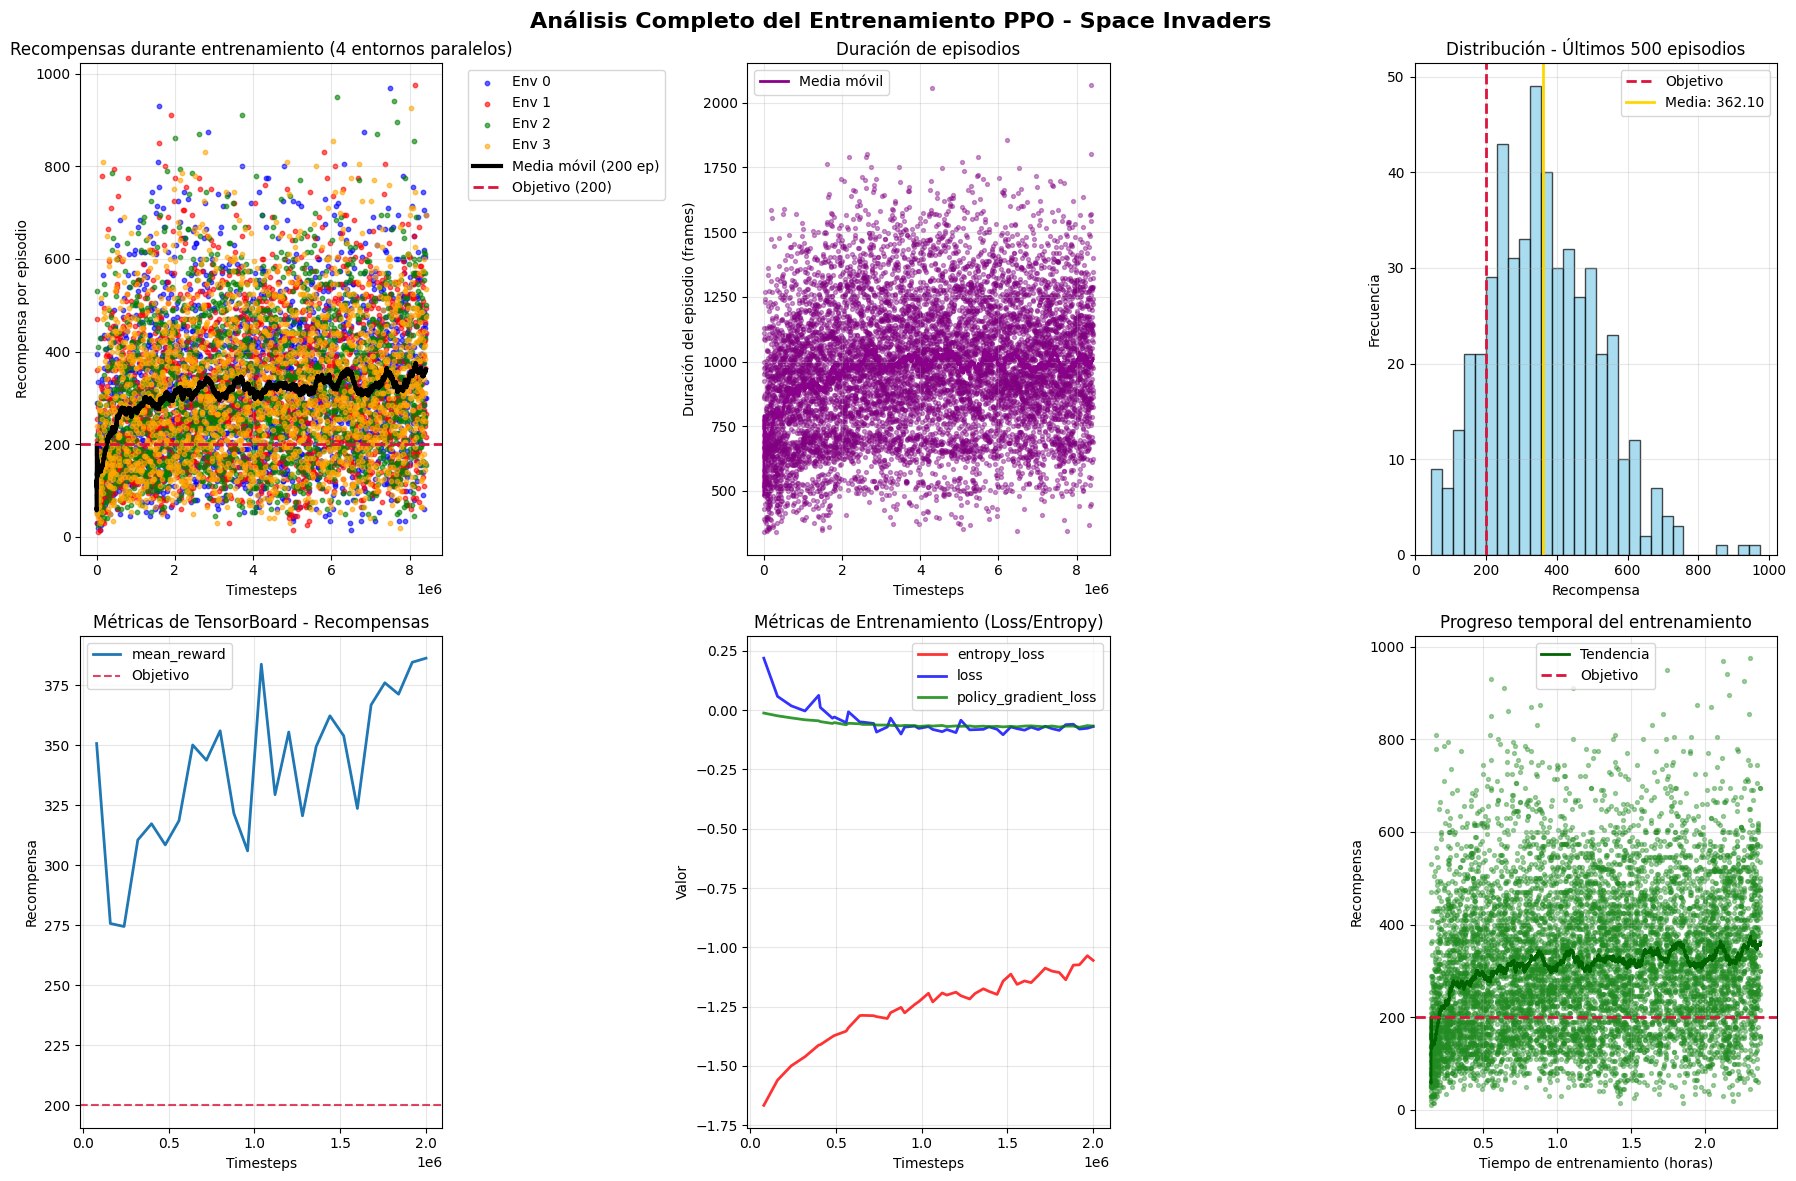


📈 ESTADÍSTICAS DETALLADAS DEL ENTRENAMIENTO

🎮 Entorno 0:
   • Episodios: 2172
   • Recompensa media: 315.75 ± 155.22
   • Mejor episodio: 970.00
   • Duración media: 969 frames

🎮 Entorno 1:
   • Episodios: 2186
   • Recompensa media: 309.57 ± 151.83
   • Mejor episodio: 975.00
   • Duración media: 963 frames

🎮 Entorno 2:
   • Episodios: 2181
   • Recompensa media: 309.52 ± 151.49
   • Mejor episodio: 950.00
   • Duración media: 965 frames

🎮 Entorno 3:
   • Episodios: 2175
   • Recompensa media: 309.57 ± 149.44
   • Mejor episodio: 925.00
   • Duración media: 968 frames

🏆 RESUMEN GLOBAL:
   • Total episodios: 8,714
   • Timesteps: 8,421,004
   • Tiempo entrenamiento: 2.37 horas
   • Recompensa media final: 362.10
   • Episodios >200 puntos: 428/500
   • Tasa de éxito: 85.6%

🎯 COMPARACIÓN CON EVALUACIÓN:
   • Entrenamiento (últimos): 362.10
   • Evaluación final: 340.00
   • Diferencia: -22.10

🔍 Archivos en c:\Users\Rodri\Documents\VS Workspace\VIUMasterInAI\7.Aprendizaje Por Ref

In [ ]:
#Visualizar Entrenamiento PPO - Análisis Completo

print("="*60)
print("📊 ANÁLISIS COMPLETO DEL ENTRENAMIENTO PPO")
print("="*60)

# --- 1. CARGAR DATOS DE MONITOR.CSV (4 ENTORNOS PARALELOS) ---
monitor_files = glob.glob(os.path.join(LOGS_DIR, "*.monitor.csv"))
print(f"\n📁 Archivos monitor encontrados: {len(monitor_files)}")

all_episodes_data = []
if monitor_files:
    for i, monitor_file in enumerate(monitor_files):
        try:
            # Leer CSV saltando la primera línea (metadatos)
            df = pd.read_csv(monitor_file, skiprows=1)
            df['env_id'] = i  # Identificar entorno
            all_episodes_data.append(df)
            print(f"   • Env {i}: {len(df)} episodios en {os.path.basename(monitor_file)}")
        except Exception as e:
            print(f"   ❌ Error leyendo {monitor_file}: {e}")

# --- 2. CARGAR DATOS DE TENSORBOARD ---
tensorboard_data = {}
tb_log_dir = os.path.join(TENSORBOARD_DIR, "PPO_1")
if os.path.exists(tb_log_dir):
    event_files = glob.glob(os.path.join(tb_log_dir, "events.out.tfevents.*"))
    if event_files:
        print(f"\n📈 TensorBoard logs encontrados: {len(event_files)}")
        try:
            ea = EventAccumulator(tb_log_dir)
            ea.Reload()
            
            # Extraer métricas clave
            scalars = ea.Tags()['scalars']
            print(f"   • Métricas disponibles: {len(scalars)}")
            
            for tag in scalars:
                if any(keyword in tag.lower() for keyword in ['reward', 'loss', 'entropy', 'value']):
                    scalar_events = ea.Scalars(tag)
                    steps = [s.step for s in scalar_events]
                    values = [s.value for s in scalar_events]
                    tensorboard_data[tag] = {'steps': steps, 'values': values}
                    
        except Exception as e:
            print(f"   ❌ Error cargando TensorBoard: {e}")

# --- 3. PROCESAR DATOS DE EPISODIOS ---
if all_episodes_data:
    # Combinar todos los entornos
    combined_df = pd.concat(all_episodes_data, ignore_index=True)
    combined_df = combined_df.sort_values('t')  # Ordenar por tiempo
    
    # Calcular timesteps acumulados
    combined_df['timestep'] = combined_df['l'].cumsum()
    
    print(f"\n📊 Resumen de datos de episodios:")
    print(f"   • Total episodios: {len(combined_df)}")
    print(f"   • Timesteps totales: {combined_df['timestep'].max():,}")
    print(f"   • Duración real: {combined_df['t'].max():.0f} segundos")
    
    # --- 4. CREAR VISUALIZACIONES ---
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Análisis Completo del Entrenamiento PPO - Space Invaders', fontsize=16, fontweight='bold')
    
    # Plot 1: Recompensas por episodio (todos los entornos)
    ax1 = axes[0, 0]
    colors = ['blue', 'red', 'green', 'orange']
    
    for env_id in range(len(monitor_files)):
        env_data = combined_df[combined_df['env_id'] == env_id]
        if len(env_data) > 0:
            ax1.scatter(env_data['timestep'], env_data['r'], 
                       alpha=0.6, s=10, c=colors[env_id], label=f'Env {env_id}')
    
    # Media móvil global
    window = min(200, len(combined_df) // 10)
    if window > 0:
        combined_df['reward_smooth'] = combined_df['r'].rolling(window=window, min_periods=1).mean()
        ax1.plot(combined_df['timestep'], combined_df['reward_smooth'], 
                color='black', linewidth=3, label=f'Media móvil ({window} ep)')
    
    ax1.axhline(y=200, color='crimson', linestyle='--', linewidth=2, label='Objetivo (200)')
    ax1.set_xlabel('Timesteps')
    ax1.set_ylabel('Recompensa por episodio')
    ax1.set_title('Recompensas durante entrenamiento (4 entornos paralelos)')
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Duración de episodios
    ax2 = axes[0, 1]
    ax2.scatter(combined_df['timestep'], combined_df['l'], alpha=0.4, s=8, c='purple')
    if window > 0:
        combined_df['length_smooth'] = combined_df['l'].rolling(window=window, min_periods=1).mean()
        ax2.plot(combined_df['timestep'], combined_df['length_smooth'], 
                color='darkmagenta', linewidth=2, label=f'Media móvil')
    ax2.set_xlabel('Timesteps')
    ax2.set_ylabel('Duración del episodio (frames)')
    ax2.set_title('Duración de episodios')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Distribución de recompensas (últimos episodios)
    ax3 = axes[0, 2]
    recent_episodes = min(500, len(combined_df))
    recent_rewards = combined_df['r'].tail(recent_episodes)
    
    ax3.hist(recent_rewards, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    ax3.axvline(x=200, color='crimson', linestyle='--', linewidth=2, label='Objetivo')
    ax3.axvline(x=recent_rewards.mean(), color='gold', linewidth=2, 
               label=f'Media: {recent_rewards.mean():.2f}')
    ax3.set_xlabel('Recompensa')
    ax3.set_ylabel('Frecuencia')
    ax3.set_title(f'Distribución - Últimos {recent_episodes} episodios')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: TensorBoard - Recompensa promedio (si disponible)
    ax4 = axes[1, 0]
    reward_metrics = [k for k in tensorboard_data.keys() if 'reward' in k.lower()]
    if reward_metrics:
        for metric in reward_metrics[:2]:  # Máximo 2 métricas
            data = tensorboard_data[metric]
            ax4.plot(data['steps'], data['values'], linewidth=2, label=metric.split('/')[-1])
        ax4.axhline(y=200, color='crimson', linestyle='--', alpha=0.8, label='Objetivo')
        ax4.set_xlabel('Timesteps')
        ax4.set_ylabel('Recompensa')
        ax4.set_title('Métricas de TensorBoard - Recompensas')
        ax4.legend()
        ax4.grid(True, alpha=0.3)
    else:
        ax4.text(0.5, 0.5, 'TensorBoard\nReward data\nno disponible', 
                ha='center', va='center', transform=ax4.transAxes, fontsize=12)
        ax4.set_title('TensorBoard - Recompensas')
    
    # Plot 5: TensorBoard - Pérdidas y Entropía
    ax5 = axes[1, 1]
    loss_metrics = [k for k in tensorboard_data.keys() if any(word in k.lower() for word in ['loss', 'entropy'])]
    if loss_metrics:
        for i, metric in enumerate(loss_metrics[:3]):
            data = tensorboard_data[metric]
            color = ['red', 'blue', 'green'][i]
            ax5.plot(data['steps'], data['values'], linewidth=2, color=color, 
                    label=metric.split('/')[-1], alpha=0.8)
        ax5.set_xlabel('Timesteps')
        ax5.set_ylabel('Valor')
        ax5.set_title('Métricas de Entrenamiento (Loss/Entropy)')
        ax5.legend()
        ax5.grid(True, alpha=0.3)
    else:
        ax5.text(0.5, 0.5, 'TensorBoard\nLoss/Entropy data\nno disponible', 
                ha='center', va='center', transform=ax5.transAxes, fontsize=12)
        ax5.set_title('TensorBoard - Pérdidas')
    
    # Plot 6: Progreso temporal (recompensa vs tiempo real)
    ax6 = axes[1, 2]
    # Convertir tiempo a horas
    combined_df['hours'] = combined_df['t'] / 3600
    ax6.scatter(combined_df['hours'], combined_df['r'], alpha=0.4, s=8, c='forestgreen')
    if 'reward_smooth' in combined_df.columns:
        ax6.plot(combined_df['hours'], combined_df['reward_smooth'], 
                color='darkgreen', linewidth=2, label='Tendencia')
    ax6.axhline(y=200, color='crimson', linestyle='--', linewidth=2, label='Objetivo')
    ax6.set_xlabel('Tiempo de entrenamiento (horas)')
    ax6.set_ylabel('Recompensa')
    ax6.set_title('Progreso temporal del entrenamiento')
    ax6.legend()
    ax6.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Guardar figura
    plot_path = os.path.join(LOGS_DIR, 'analisis_completo_ppo.png')
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    print(f"\n📊 Análisis completo guardado: {plot_path}")
    
    plt.show()
    
    # --- 5. ESTADÍSTICAS FINALES ---
    print("\n" + "="*60)
    print("📈 ESTADÍSTICAS DETALLADAS DEL ENTRENAMIENTO")
    print("="*60)
    
    # Estadísticas por entorno
    for env_id in range(len(monitor_files)):
        env_data = combined_df[combined_df['env_id'] == env_id]
        if len(env_data) > 0:
            print(f"\n🎮 Entorno {env_id}:")
            print(f"   • Episodios: {len(env_data)}")
            print(f"   • Recompensa media: {env_data['r'].mean():.2f} ± {env_data['r'].std():.2f}")
            print(f"   • Mejor episodio: {env_data['r'].max():.2f}")
            print(f"   • Duración media: {env_data['l'].mean():.0f} frames")
    
    # Estadísticas globales
    print(f"\n🏆 RESUMEN GLOBAL:")
    print(f"   • Total episodios: {len(combined_df):,}")
    print(f"   • Timesteps: {combined_df['timestep'].max():,}")
    print(f"   • Tiempo entrenamiento: {combined_df['t'].max()/3600:.2f} horas")
    print(f"   • Recompensa media final: {recent_rewards.mean():.2f}")
    print(f"   • Episodios >200 puntos: {(recent_rewards > 200).sum()}/{len(recent_rewards)}")
    print(f"   • Tasa de éxito: {(recent_rewards > 200).mean()*100:.1f}%")
    
    # Comparar con evaluación final
    if 'mean_reward' in locals():
        print(f"\n🎯 COMPARACIÓN CON EVALUACIÓN:")
        print(f"   • Entrenamiento (últimos): {recent_rewards.mean():.2f}")
        print(f"   • Evaluación final: {mean_reward:.2f}")
        print(f"   • Diferencia: {mean_reward - recent_rewards.mean():+.2f}")
    
    print("="*60)

else:
    print("❌ No se encontraron datos de monitor para analizar")
    print("💡 Verifica que el entrenamiento se haya completado correctamente")

# Mostrar archivos disponibles para debug
print(f"\n🔍 Archivos en {LOGS_DIR}:")
for file in os.listdir(LOGS_DIR)[:10]:  # Mostrar solo los primeros 10
    size = os.path.getsize(os.path.join(LOGS_DIR, file)) / 1024
    print(f"   • {file} ({size:.1f} KB)")

### Conclusiones

#### Comparación de Arquitecturas:


##### **Similitudes Estructurales **

| Componente | Modelo 3 - PyTorch/SB3 | Modelo 1 - Keras/TensorFlow |
|------------|------------------------|------------------------------|
| **Conv 1** | 32 filtros, 8×8, stride=4 | 32 filtros, 8×8, stride=4 |
| **Conv 2** | 64 filtros, 4×4, stride=2 | 64 filtros, 4×4, stride=2 |
| **Conv 3** | 64 filtros, 3×3, stride=1 | 64 filtros, 3×3, stride=1 |
| **Flatten** | 3136 valores | 3136 valores |
| **Dense 1** | 512 neuronas | 512 neuronas |
| **Dense 2** | 6 acciones | 6 acciones |
| **Parámetros** | ~1.5M | ~1.6M |





##### **1. Framework y Compatibilidad GPU**
- **Modelo 1 (Keras)**: TensorFlow backend → **NVIDIA GPU (CUDA)** - (D3QN) Dueling Double Deep Q-network
- **Modelo 3 (PyTorch)**: PyTorch backend → **AMD GPU (ROCm)** - (DQN) Value-Based Deep Q-Network con una red convlocional

##### **2. Estructura del Agente DQN**

**Keras/Keras-RL (Modelo 1):**
```
Red Base Simple → Keras-RL agrega Dueling/Double DQN externamente
- enable_dueling_network=True
- enable_double_dqn=True
- La red solo calcula Q-values básicos
```

**PyTorch/SB3 (Modelo 3):**
```
Arquitectura Completa con 2 Subredes:
├─ q_net (red principal - se entrena constantemente)
└─ q_net_target (copia estable - actualización periódica)

Cada una contiene:
├─ NatureCNN (extractor de características convolucionales)
└─ QNetwork (cabeza de decisión con 6 salidas)
```

##### **3. Preprocesamiento de Entrada**

**Keras necesita `Permute((2, 3, 1))`:**
- Reorganiza: `(4, 84, 84)` → `(84, 84, 4)`
- Keras espera canales al final (channels-last)

**PyTorch NO la necesita:**
- Procesa `(4, 84, 84)` directamente
- Formato channels-first por defecto

---

#### **Rendimiento Esperado**

Dado que ambas usan la **misma arquitectura convolucional**, el rendimiento debería ser similar si:
- Se usan hiperparámetros equivalentes
- Se entrenan el mismo número de pasos
- La implementación de DQN es correcta

##### **Ventajas del Modelo 1 (Keras/TF)**
- ✅ Keras-RL integra Dueling DQN nativamente
- ✅ Código compacto
- ✅ Optimizado para NVIDIA GPU

##### **Ventajas del Modelo 3 (PyTorch/SB3)**
- ✅ Stable-Baselines3 más moderno y mantenido activamente
- ✅ Compatible con **AMD GPU** (ROCm)
- ✅ TensorBoard integrado
- ✅ Callbacks avanzados (EvalCallback, CheckpointCallback)
- ✅ API más simple y consistente

---

#### **Resumen**

Los modelos son **funcionalmente equivalentes** - la arquitectura CNN es idéntica (NatureCNN de DeepMind). La elección depende del hardware disponible:

- **GPU NVIDIA** → Modelo 1 (TensorFlow + Keras-RL)
- **GPU AMD** → Modelo 4 (PyTorch + Stable-Baselines3)
